## LIBRARIES

In [75]:
# import libraries 
import pandas as pd
import numpy as np
import re
import textwrap
from itertools import combinations

from scipy import stats
from statsmodels.stats.multitest import multipletests

import seaborn as sns
import matplotlib.pyplot as plt

import matplotlib.ticker as ticker

import ipywidgets as widgets
from IPython.display import display

import plotly.graph_objects as go
from plotly.subplots import make_subplots

## FUNCTIONS

### CLEAN SURVEY DATA

#### HELPERS

In [76]:
# define tier ranges for theme columns, & add in T# prefix to the research topic column 
tier_ranges = {
    'T1': list(range(28, 40)) + [43, 44]
    , 'T2': list(range(46, 65))
    , 'T3': list(range(16, 19)) + list(range(20, 26)) + [40, 42]
    , 'T4': list(range(1, 16))
    , 'T5': list(range(65, 73))
    , 'T6': [19, 26, 27, 45] + list(range(73, 77)) + list(range(86, 93))
    , 'T7': [41] + list(range(77, 86))
    , 'T8': list(range(93, 98))
}

In [77]:
# helper function to get research-topic columns
def get_tier(col, tier_ranges):
    try:
        n = int(str(col).split('.')[0].strip())
        for tier, r in tier_ranges.items():
            if n in r:
                return tier
    except ValueError:
        pass
    return None

#### ROUND 1 

In [78]:
def clean_survey_data(df):
    '''
    function to clean the new Welphi survey data 
        - drops last 3 columns 
        - combines metadata columns & moves metadata to the end 
        - adds Stakeholder Group
        - renames question columns (
            T1: 28-39, 43, 44
            T2: 46-64
            T3: 16-18, 20-25, 40, 42
            T4: 1-15
            T5: 65-72
            T6: 19, 26, 27, 45, 73-76, 86-92
            T7: 41, 77-85
            T8: 93-97
            ) 
        - converts columns to floats
    input: dataframe to clean 
    output: cleaned and transformed dataframes
    '''
    # drop 'optional' columns (see column headers for more info about what these are)
    optional_cols = [
        c for c in df.columns 
        if str(c).startswith('(Optional)')
        ]
    df = df.drop(columns=optional_cols)

    # combine paired columns, and replace main column with open text cell 
    paired_cols = [
        (
            '1. Please select all the NMOSD/MOGAD stakeholder communities with which you identify.',
            '1. I prefer to self-describe (please specify) [open text]'
        ),
        (
            '2. What is your gender?',
            '2. I prefer to self-describe (please specify) [open text]'
        ),
        (
            '3. What is your ethnicity?',
            '3. Other (please specify) [open text]'
        ),
        (
            '5. Which condition are you (or your loved one) impacted by?',
            '5. Uncertain/other (please specify) [open textbox]'
        ),
        (
            "11. What is your (or your loved one's) primary employment status?",
            '11. Other (please specify) [open textbox]'
        ),
        (
            '12. What is the highest level of education that you (or your loved one) has completed?',
            '12. Other (please specify) [open textbox]'
        ),
        (
            '13. In which type of area do you (or your loved one) currently live?',
            '13. Other (please specify) [open textbox]'
        ),
    ]

    # if they both exist in the dataframe:
    for main_col, text_col in paired_cols:
        if main_col in df.columns and text_col in df.columns:
            # make sure they are real (no NaN, blank columns, or -) 
            mask = (df[text_col].notna() & (df[text_col].str.strip() != '') & (df[text_col].str.strip() != '-'))
            df.loc[mask, main_col] = df.loc[mask, text_col]
            df = df.drop(columns=[text_col])

    # add 'Stakeholder Group' column after Participants
    stakeholder_col = '1. Please select all the NMOSD/MOGAD stakeholder communities with which you identify.'
    df.insert(
        df.columns.get_loc('Participants') + 1,
        'Stakeholder Group',
        df[stakeholder_col]
    )

    # move metadata columns to the end of the dataframe 
    lang_col  = 'Language that survey was completed in'
    other_col = '13. In which type of area do you (or your loved one) currently live?'

    lang_idx  = df.columns.get_loc(lang_col)
    other_idx = df.columns.get_loc(other_col)

    move_cols = list(df.columns[lang_idx : other_idx + 1])
    stay_cols = [c for c in df.columns if c not in move_cols]
    df = df[stay_cols + move_cols]

    demo_start_idx = df.columns.get_loc(lang_col)

    # rename columns with the tier 
    rename_map = {}
    for col in df.columns[:demo_start_idx]:
        tier = get_tier(col, tier_ranges)
        if tier:
            rename_map[col] = f'{tier}: {col}'

    df = df.rename(columns=rename_map)

    # convert to float, replace '-' with NaN 
    # recalculate after renaming 
    demo_start_idx = df.columns.get_loc(lang_col)
    for col in df.columns[:demo_start_idx]:
        df[col] = df[col].replace('-', np.nan)
        try:
            df[col] = df[col].astype(float)
        except (ValueError, TypeError):
            # leave non-numeric columns (e.g. Participants, Stakeholder Group)
            pass 

    # replace '-' with NaN for metadata column 
    for col in df.columns[demo_start_idx:]:
        df[col] = df[col].replace('-', np.nan)

    return df

#### ROUND 2

In [79]:
def clean_survey_data_welphi_r2(df):
    '''
    function to clean the round 2 Welphi survey data 
        - drops optional columns
        - renames question columns with T#: prefix
        - converts question columns to floats
    input: dataframe to clean 
    output: cleaned dataframe
    '''
    # drop optional columns
    optional_cols = [
        c for c in df.columns
        if str(c).startswith('(Optional)')
    ]

    df = df.drop(columns=optional_cols)

    # rename research-topic columns
    rename_map = {}
    for col in df.columns:
        tier = get_tier(col, tier_ranges)
        if tier:
            rename_map[col] = f'{tier}: {col}'
    df = df.rename(columns=rename_map)

    # convert renamed research-topic columns to float
    research_cols = list(rename_map.values())
    for col in research_cols:
        df[col] = df[col].replace(['-', 'N/A'], np.nan)
        try:
            df[col] = df[col].astype(float)
        except (ValueError, TypeError):
            pass

    # replace '-' with NaN in remaining metadata columns
    metadata_cols = [c for c in df.columns if c not in research_cols]

    for col in metadata_cols:
        df[col] = df[col].replace('-', np.nan)

    return df

### SUMMARIZE COLUMN: RETURN FREQUENCY TABLE, USED IN DATASET DEMOGRAPHICS

In [80]:
def summarize_column(df, col):
    ''' 
    function to summarize columns and return the data as a frequency table 
    inputs: 
        - dataframe to be used 
        - column to turn into a frequency table 
    output: frequency table 
    '''
    counts = df[col].dropna().value_counts()

    freq_table = (
        counts
        .rename_axis('Category')
        .reset_index(name='Count')
    )

    ax = freq_table.plot(
        x='Category',
        y='Count',
        kind='bar',
        legend=False,
        figsize=(8,5)
    )

    for container in ax.containers:
        ax.bar_label(container)

    plt.title(col.replace('_clean', ""))
    plt.ylabel('Count')
    plt.xlabel("")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    return freq_table

### HELPER: HEATMAP TRACE, USED IN THEME EXPLORATION

In [81]:
def heatmap_trace(df_long, group_label):
    agg = (
        df_long
        .groupby(['theme', 'question'])['rating']
        .agg(mean='mean', std='std', count='count')
        .reset_index()
    )

    # sort to group questions by theme
    agg = agg.sort_values(['theme', 'question'])
    ordered_questions = agg.drop_duplicates('question')['question'].tolist()

    # get mean, standard deviation and count information 
    pivot_mean  = agg.pivot(index='theme', columns='question', values='mean')
    pivot_std   = agg.pivot(index='theme', columns='question', values='std')
    pivot_count = agg.pivot(index='theme', columns='question', values='count')

    pivot_mean  = pivot_mean.reindex(columns=ordered_questions)
    pivot_std   = pivot_std.reindex(columns=ordered_questions)
    pivot_count = pivot_count.reindex(columns=ordered_questions)

    themes    = pivot_mean.index.tolist()
    questions = pivot_mean.columns.tolist()
    z         = pivot_mean.values

    # add in hover buttons to display stats when you hover over each component of the graph
    hover = []
    for i, theme in enumerate(themes):
        row = []
        for j, q in enumerate(questions):
            mn = pivot_mean.iloc[i, j]
            sd = pivot_std.iloc[i, j]
            n  = pivot_count.iloc[i, j]
            mn_display = f"{mn:.2f}" if not pd.isna(mn) else "—"
            sd_display = f"{sd:.2f}" if not pd.isna(sd) else "—"
            n_display  = f"{int(n)}" if not pd.isna(n)  else "—"
            row.append(
                f"<b>{q}</b><br>"
                f"Group: {group_label}<br>"
                f"Theme: {theme}<br>"
                f"Mean: {mn_display}<br>"
                f"Std dev: {sd_display}<br>"
                f"n respondents: {n_display}"
            )
        hover.append(row)

    # return heatmap object
    return go.Heatmap(
        z=z,
        x=questions,
        y=themes,
        text=hover,
        hovertemplate="%{text}<extra></extra>",
        colorscale="RdYlGn",
        zmid=pivot_mean.stack().median(),
        showscale=True,
        xgap=2, ygap=2,
        name=group_label,
    )

### THEME RANKINGS

In [82]:
def theme_rankings(df_long, group_label='All participants'):
    '''
    function to summarize and rank question ratings in each theme (discriptive stats, rankings of questions, and label for participant group)
    input 
        - long dataframe (columns: theme, question_number, question_text, rating)
        - group label 
    output: summary of data 
    '''
    # define summary for theme rankings
    summary = (
        # remove any missing ratings 
        df_long.dropna(subset=['rating'])
        # group data by theme/question number/question and rating 
        .groupby(['theme', 'question_number', 'question_text'])['rating']
        # summary statistics (number of ratings, average rating, median rating, standard deviation, interquartile range, % of ratings ≥ 7)
        .agg(
            n='count',
            mean=lambda x: round(x.mean(), 3),
            median='median',
            sd=lambda x: round(x.std(), 3),
            iqr=lambda x: round(x.quantile(0.75) - x.quantile(0.25), 3),
            pct_7plus=lambda x: round((x >= 7).mean() * 100, 1)
        )
        # convert to dataframe 
        .reset_index()
    )

    # rank within each theme by median desc, then mean desc (because median is a good measure of this type of data, and mean can be used to stratify it as a tiebreaker)
    summary['rank_in_theme'] = (
        # rank highest median first then mean 
        summary.groupby('theme')[['median', 'mean']]
        .rank(method="min", ascending=False)
        # tiebreak: combine the two ranks into one number (median first, then mean is a tiebreaker)
        .apply(lambda x: x['median'] + x['mean'] * 0.001, axis=1) 
    )
    # convert to integer
    summary['rank_in_theme'] = summary.groupby('theme')['rank_in_theme'].rank(method='min').astype(int)

    # sort values by theme and rank 
    summary = summary.sort_values(['theme', 'rank_in_theme'])

    # create group label (for all participants)
    summary['group'] = group_label

    # return summary 
    return summary

### COMPARE RANKINGS: SPLIT BY LIVED EXPERIENCE

In [83]:
def compare_rankings(ranks_a, ranks_b, label_a, label_b):
    '''
    function to compare how people with lived experience ranked questions vs professionals
    input: 
        - 1st group ranking 
        - 2nd group ranking
        - 1st group label 
        - 2nd group label 
    output: merged dataframe for 
    '''
    # keep the theme, question, and stats columns for each group 
    merged = ranks_a[['theme','question_number','question_text','rank_in_theme','median','pct_7plus']].merge(
        ranks_b[['theme','question_number','question_text','rank_in_theme','median','pct_7plus']],
        on=['theme','question_number','question_text'],
        suffixes=(f"_{label_a}", f"_{label_b}")
    )

    # calculate ranking disagreement, where a larger rank difference means stronger disagreement 
    merged['rank_diff'] = (merged[f"rank_in_theme_{label_a}"] - merged[f"rank_in_theme_{label_b}"]).abs()

    # sort by theme and ranking from 1st group (lived experience)
    return merged.sort_values(['theme', f"rank_in_theme_{label_a}"])

### CREATE SCATTERPLOTS (COLUMN COMPARISON)

In [84]:
def plot_column_comparison(df, comparison_col, group_a, group_b_list, label_a, label_b, theme_description_tier_ranges, theme_label_map, ncols=3, figsize_per_panel=(5, 5), secondary_title=None):
    '''
    function to generate a scatter plot based on groupings in a column - calculate means, merge, plot
    input: 
        - dataframe 
        - comparison column 
        - 1st group to be compared
        - 2nd group(s) to be compared (as list)
        - label for group 1
        - label for group 2
        - tier ranges 
        - theme label map 
        - number of columns = 3
        - figure size = 5x5
    output: scatterplots for column comparisons 
    '''
    # group by question/theme number/comparison column and rating, caluclate average rating within each group 
    group_means = (
        df.groupby(['question_number', 'theme_description', comparison_col])['rating']
        .mean()
        .reset_index()
    )

    # side a is the comparison column group means, side b is the grouping of question number and theme description by rating 
    side_a = group_means[group_means[comparison_col] == group_a]

    # mean across selected groups - mean if the comparison column is in the list of group b columns 
    side_b = (
        group_means[group_means[comparison_col].isin(group_b_list)]
        .groupby(['question_number', 'theme_description'])['rating']
        .mean()
        .reset_index()
    )

    # merge side a and side b to get one matrix of data
    merged = side_a.merge(
        side_b,
        on=['question_number', 'theme_description'],
        suffixes=('_a', '_b')
    )

    # get theme order so that it displays from T1-T8
    theme_order = list(theme_description_tier_ranges.keys())
    themes = [t for t in theme_order if t in merged['theme_description'].unique()]

    # get number of rows and columns for the figure size 
    nrows = -(-len(themes) // ncols)
    fw = figsize_per_panel[0] * ncols
    fh = figsize_per_panel[1] * nrows

    fig, axes = plt.subplots(nrows, ncols, figsize=(fw, fh))
    axes = axes.flatten()

    for ax, theme_desc in zip(axes, themes):
        data = merged[merged['theme_description'] == theme_desc]
        x = data['rating_a']
        y = data['rating_b']

        ax.scatter(x, y, alpha=0.75, s=60, color="#1E2E86", edgecolors='white', linewidths=0.5)

        for _, row in data.iterrows():
            ax.annotate(
                str(int(row['question_number'])),
                (row['rating_a'], row['rating_b']),
                fontsize=7, ha='left', va='bottom',
                xytext=(3, 3), textcoords='offset points', color='#555'
            )

        pad = 0.3
        lo = min(x.min(), y.min()) - pad
        hi = max(x.max(), y.max()) + pad
        ax.plot([lo, hi], [lo, hi], color="#aaa", linewidth=1, linestyle="--", zorder=0)
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.set_aspect('equal')

        theme_label = theme_label_map.get(theme_desc, "")
        wrapped = textwrap.fill(theme_desc, width=35)
        ax.set_title(f"{theme_label}: {wrapped}", fontsize=10, fontweight="bold")
        ax.set_xlabel(f"{label_a} (mean rating)", fontsize=9)
        ax.set_ylabel(f"{label_b} (mean rating)", fontsize=9)
        ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=False, nbins=5))
        ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=False, nbins=5))
        ax.grid(True, linewidth=0.4, alpha=0.5)

    for ax in axes[len(themes):]:
        ax.set_visible(False)

    fig.suptitle(f"{label_a} vs {label_b} — mean ratings by theme\n(dashed line = agreement)",
                 fontsize=13, y=1.02)

    if secondary_title:
        fig.text(0.5, 0.985, secondary_title, ha='center', va='top', fontsize=10, color='#555')
    
    plt.tight_layout()
    plt.show()

### CREATE SCATTERPLOTS (STANDARD AXIS) & BLAND-ALTMAN

In [85]:
threshold = 7
keys = ['question_number', 'theme_description'] 

def summarize_comparison(df, comparison_col, group_a, group_b_list, threshold=threshold):
    ''' 
    function to create a summary for 2 comparison groups 
    input:
        - dataframe with question_number, theme_description, rating, comparison_col
        - comparison column
        - 1st group to be compared
        - 2nd group(s) to be compared (as list)
        - threshold: number rating that would be "important" 
    output: merged dataframe with one row per question (with labels _a / _b):
        - n
        - mean 
        - percent above threshold 
        - difference and average for group A and B for mean and the percent above threshold 
    '''
    df = df.dropna(subset=['rating'])

    # summarize the two groups (A and B)
    def helper_summarize(sub):
        return (
            sub.groupby(keys)['rating']
            .agg(
                n='count',
                mean='mean',
                pct_high=lambda r: (r >= threshold).mean() * 100,
            )
            .reset_index()
        )

    # summarize and merge two dataframes 
    side_a = helper_summarize(df[df[comparison_col] == group_a])
    side_b = helper_summarize(df[df[comparison_col].isin(group_b_list)])
    merged = side_a.merge(side_b, on=keys, suffixes=('_a', '_b'))

    # calculate the averages for the mean and the percentage above the high threshold 
    for metric in ('mean', 'pct_high'):
        merged[f'diff_{metric}'] = merged[f'{metric}_a'] - merged[f'{metric}_b']
        merged[f'avg_{metric}'] = (merged[f'{metric}_a'] + merged[f'{metric}_b']) / 2

    return merged

In [86]:
# other helper functions
def helper_ordered_themes(merged, theme_description_tier_ranges):
    ''' 
    function to oder the themes according to the tier ranges 
    '''
    present = set(merged['theme_description'])
    return [t for t in theme_description_tier_ranges if t in present]


def helper_make_grid(n_panels, ncols, figsize_per_panel):
    ''' 
    function to make a grid based on the number of panels and columns 
    '''
    # set the number of rows based on panels & columns 
    nrows = -(-n_panels // ncols)
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(figsize_per_panel[0] * ncols, figsize_per_panel[1] * nrows),
        squeeze=False,  
    )
    # * if it is always a 2D array, .flatten() will work even if there is 1 panel
    axes = axes.flatten()
    for ax in axes[n_panels:]:
        ax.set_visible(False)
    return fig, axes


def helper_style_panel(ax, theme_desc, theme_label_map, xlabel, ylabel):
    ''' 
    function to set the panel format 
    '''
    label = theme_label_map.get(theme_desc, '')
    ax.set_title(f"{label}: {textwrap.fill(theme_desc, width=35)}", fontsize=10, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
    ax.grid(True, linewidth=0.4, alpha=0.5)


def helper_label_points(ax, data, x_col, y_col, diff_col, label_threshold=None):
    '''
    function to label every point (or only label points with |difference| >= label_threshold)
    '''
    for _, row in data.iterrows():
        # if the there is a threshold and the difference is greater than that 
        if label_threshold is not None and abs(row[diff_col]) < label_threshold:
            continue
        ax.annotate(
            str(int(row['question_number'])),
            (row[x_col], row[y_col]),
            fontsize=7, ha='left', va='bottom',
            xytext=(3, 3), textcoords='offset points', color='#555',
        )


def helper_finish(fig, title, secondary_title):
    ''' 
    function to show the finished figure 
    '''
    fig.suptitle(title, fontsize=13, y=1.02)
    if secondary_title:
        fig.text(0.5, 0.985, secondary_title, ha='center', va='top',
                 fontsize=10, color='#555')
    plt.tight_layout()
    plt.show()

In [87]:
labels = {'mean': 'mean rating', 'pct_high': f'% rating {threshold}–9'}

def plot_column_comparison_for_BA(merged, label_a, label_b, theme_description_tier_ranges, theme_label_map, metric='mean', axis_limits=None, label_threshold=None, ncols=3, figsize_per_panel=(5, 5), secondary_title=None, save_path=None):
    '''
    function to plot the comparison columns with the metric for comparison as the mean or the pct_high (scatter plot vs line of equality)
    * the axis limits are set for x and y on every panel (with contingency that if there are no limits, to calculate it from all the themes together and that is the same for every figure)
    * label_threshold: only label questions whose |A - B| is at least this so it would be easier to see the differences 
    '''
    # set column a and column b metrics 
    col_a, col_b = f'{metric}_a', f'{metric}_b'
    unit = labels[metric]

    # if there is no axis limit, calculate it from the merged dataframes 
    if axis_limits is None:
        values = pd.concat([merged[col_a], merged[col_b]])
        pad = 0.3 if metric == 'mean' else 5
        axis_limits = (values.min() - pad, values.max() + pad)
    lo, hi = axis_limits

    # set the order of the themes and set the figure sizes 
    themes = helper_ordered_themes(merged, theme_description_tier_ranges)
    fig, axes = helper_make_grid(len(themes), ncols, figsize_per_panel)

    # for the axes and themes, merge on the description and set to descending 
    for ax, theme_desc in zip(axes, themes):
        data = merged[merged['theme_description'] == theme_desc]
        ax.plot([lo, hi], [lo, hi], color='#aaa', linewidth=1, linestyle='--', zorder=0)
        ax.scatter(data[col_a], data[col_b], alpha=0.75, s=60, color='#1E2E86', edgecolors='white', linewidths=0.5)
        helper_label_points(ax, data, col_a, col_b, f'diff_{metric}', label_threshold)
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.set_aspect('equal')
        helper_style_panel(ax, theme_desc, theme_label_map,
                     f'{label_a} ({unit})', f'{label_b} ({unit})')

    title = f"{label_a} vs {label_b} — {unit} by theme\n(dashed line = agreement)"
    return helper_finish(fig, title, secondary_title)

In [88]:
labels = {'mean': 'mean rating', 'pct_high': f'% rating {threshold}–9'}

def plot_bland_altman(merged, label_a, label_b, theme_description_tier_ranges, theme_label_map, metric='mean', x_limits=None, y_limits=None, label_threshold=None, ncols=3, figsize_per_panel=(5, 4), secondary_title=None, save_path=None):
    '''
    function to create a Bland-Altman plot: a method comparison chart that helps you see how closely two measurement methods agree (method of data plotting used in analyzing the agreement between two different assays) where 
        - x = average of the two groups
        - y = A - B (and positive = group A rated higher)
    bias is calculated as the mean difference and the "limits of agreement are 95% (calculated across all questions and are the same for every panel)
    '''
    # calculate metrics 
    avg_col, diff_col = f'avg_{metric}', f'diff_{metric}'
    unit = labels[metric]

    # get the differences and the biases 
    diffs = merged[diff_col]
    bias = diffs.mean()
    sd = diffs.std(ddof=1)
    # in a normal distribution, 95% of values fall within 1.96 standard deviations of the mean, with 2.5% cut off in each tail
    # "mean ± 1.96 × SD" = range where we would expect about 95% of values to land
    loa_low, loa_high = bias - 1.96 * sd, bias + 1.96 * sd

    if x_limits is None:
        pad = 0.2 if metric == 'mean' else 5
        x_limits = (merged[avg_col].min() - pad, merged[avg_col].max() + pad)
    if y_limits is None:
        reach = max(diffs.abs().max(), abs(loa_low), abs(loa_high)) * 1.15
        y_limits = (-reach, reach)  # symmetric, so zero sits in the middle

    # set theme order and figure style
    themes = helper_ordered_themes(merged, theme_description_tier_ranges)
    fig, axes = helper_make_grid(len(themes), ncols, figsize_per_panel)

    # plot and label points 
    for ax, theme_desc in zip(axes, themes):
        data = merged[merged['theme_description'] == theme_desc]

        ax.axhline(0, color='#aaa', linewidth=1, zorder=0)
        ax.axhline(bias, color='#C0392B', linewidth=1.2, linestyle='--', zorder=0)
        for loa in (loa_low, loa_high):
            ax.axhline(loa, color='#C0392B', linewidth=0.8, linestyle=':', zorder=0)

        ax.scatter(data[avg_col], data[diff_col], alpha=0.75, s=60, color='#1E2E86',
                   edgecolors='white', linewidths=0.5)
        helper_label_points(ax, data, avg_col, diff_col, diff_col, label_threshold)

        ax.text(0.02, 0.03, f"theme mean diff = {data[diff_col].mean():+.2f}",
                transform=ax.transAxes, fontsize=8, va='bottom', color='#555')

        ax.set_xlim(*x_limits)
        ax.set_ylim(*y_limits)
        helper_style_panel(ax, theme_desc, theme_label_map,
                     f'Average of both groups ({unit})',
                     f'{label_a} − {label_b}')

    title = (f"{label_a} vs {label_b} — difference in {unit} by theme\n"
             f"(solid = no difference, dashed = mean difference {bias:+.2f}, "
             f"dotted = 95% limits of agreement {loa_low:+.2f} to {loa_high:+.2f})")
    return helper_finish(fig, title, secondary_title)

## DATA

### RAW DATA (OLD)

### RAW DATA (UPDATED SEPTEMBER 4TH)

In [ ]:
# Round 1 data 
r1_raw = pd.read_csv('/path/to/file')

# clean
r1 = clean_survey_data(r1_raw)

# ----------------------------------------------------------------------------------- #

# round 2 data
r2_raw = pd.read_csv('/path/to/file')

# clean 
r2 = clean_survey_data_welphi_r2(r2_raw)

In [91]:
len(r1)

390

In [92]:
len(r2)

129

## CONVERT TO LONG DF 

In [93]:
# convert to long format
df1 = r1.copy()

# identifier columns
id_cols = ['Participants', 'Stakeholder Group']

# theme columns
theme_cols = [c for c in df1.columns if c.startswith(('T1:', 'T2:', 'T3:', 'T4', 'T5:', 'T6:', 'T7:', 'T8:'))]

# all remaining columns are metadata
meta_cols = [c for c in df1.columns if c not in id_cols + theme_cols]

# melt to long format
df1_long = df1.melt(
    id_vars=id_cols + meta_cols,
    value_vars=theme_cols,
    var_name='theme_and_question',
    value_name='rating'
)

# extract theme
df1_long['theme'] = df1_long['theme_and_question'].str.extract(r'^(T\d+(?:\.\d+)?)')

# extract question text
df1_long['question'] = (
    df1_long['theme_and_question']
    .str.replace(r'^T\d+(?:\.\d+)?:\s*', '', regex=True)
    .str.strip()
)

# extract numeric question number
df1_long['question_number'] = df1_long['question'].str.extract(r'^(\d+)')

# remove leading number from question text
df1_long['question_text'] = (
    df1_long['question']
    .str.replace(r'^\d+\.?\s*', '', regex=True)
)

## REMAP DATA: METADATA COLUMNS

In [94]:
# gender 
gender_map = {
    "Female": "Female",
    "Male": "Male",

    "Non-Binary": "Gender Diverse",
    "Genderfluid": "Gender Diverse",
    "Other (please specify)": "Gender Diverse",

    "I prefer not to answer": "Prefer not to answer"
}

# ethnicity 
ethnicity_map = {
    "African": "Black",
    "African American": "Black",
    "Black": "Black",
    "Black American": "Black",

    "Arab": "ME/NA",
    "Middle Eastern": "ME/NA",
    "Nord africaine": "ME/NA",

    "East Asian": "East Asian",
    "South Asian": "South Asian",

    "Latino": "Latino",

    "Native American": "Native American",

    "White": "White",

    "Mixed ethnicity": "Mixed Ethnicity",
    "African,Mixed ethnicity": "Mixed Ethnicity",
    "Latino,Mixed ethnicity": "Mixed Ethnicity",
    "White,African": "Mixed Ethnicity",
    "White,East Asian": "Mixed Ethnicity",
    "East Asian,South Asian": "Mixed Ethnicity",
    "White,Latino,Mixed ethnicity": "Mixed Ethnicity",
    "White,African,South Asian,Mixed ethnicity": "Mixed Ethnicity",
    "White,African,East Asian,Mixed ethnicity": "Mixed Ethnicity",

    "Other / self-describe (please specify)": "Other",
    "France": "Other", 
    "I prefer not to answer": "Other"
}

# country 
country_map = {
    # United States 
    "US": "United States",
    "USA": "United States",
    "Usa": "United States",
    "us": "United States",

    # United Kingdon 
    "England": "United Kingdom",
    "Scotland": "United Kingdom",
    "United Kingdom": "United Kingdom",

    # Latin America
    "Argentina": "Latin America",
    "Brazil": "Latin America",
    "Chile": "Latin America",
    "Colombia": "Latin America",

    # Europe
    "France": "Europe",
    "france": "Europe",
    "Germany": "Europe",
    "Belgium": "Europe",

    "Italy": "Europe",
    "Italia": "Europe",

    "Spain": "Europe",
    "Switzerland": "Europe",
    "Sweden": "Europe",
    "Norway": "Europe",
    "Denmark": "Europe",
    "Poland": "Europe",
    "The Netherlands": "Europe",
    "Ukraine": "Europe",

    # Asia
    "China": "Asia",
    "India": "Asia",
    "Japan": "Asia",
    "South Korea": "Asia",
    "Malaysia": "Asia",
    "Pakistan": "Asia",
    "Saudi Arabia": "Asia",
    "Iran": "Asia",
    "Turkiye": "Asia",

    # Africa
    "South Africa": "Africa",
    "Botswana": "Africa",
    "Egypt": "Africa",
    "Morocco": "Africa",
    "Tunisia": "Africa",
    "Togo": "Africa",

    # Oceania
    "Australia": "Oceania",
    "New Zealand": "Oceania",

    # Other
    "USA, Mexico, Canada": "Multiple Countries",
    "Prefer not to answer": "Prefer not to answer"
}

# years living with disease 
duration_map = {
    "Less than two years": "< 2 years",

    "Two to four years": "2-4 years",

    "Five to 10 years": "5-10 years",

    "11 to 20 years": "11-20 years",

    "20 years or more": "20+ years",
    "More than 20 years": "20+ years",

    "I don't remember/not sure": "Unknown"
}

# age at diagnosis 
age_dx_map = {
    "As an infant/toddler (birth to 3 years of age)": "0-3",

    "In childhood (3 to 9 years of age)": "4-9",
    "In childhood (4-9 years)": "4-9",

    "In adolescence (10 to 17 years of age)": "10-17",

    "As a young adult (18 to 39 years of age)": "18-39",
    "As a young adult (18 to 39 years)": "18-39",

    "In middle-adulthood (40-64 years of age)": "40-64",
    "In middle-adulthood (40-64 years)": "40-64",

    "As a senior (65 +)": "65+"
}

# year diagnosed 
year_dx_map = {
    "Before 2000": "Before 2000",

    "2004": "2000-2009",
    "2006": "2000-2009",
    "2007": "2000-2009",
    "2008": "2000-2009",
    "2009": "2000-2009",

    "2010": "2010-2014",
    "2011": "2010-2014",
    "2012": "2010-2014",
    "2013": "2010-2014",
    "2014": "2010-2014",

    "2015": "2015-2019",
    "2016": "2015-2019",
    "2017": "2015-2019",
    "2018": "2015-2019",
    "2019": "2015-2019",

    "2020": "2020-2025",
    "2021": "2020-2025",
    "2022": "2020-2025",
    "2023": "2020-2025",
    "2024": "2020-2025",
    "2025": "2020-2025",

    "I don't remember/not sure": "Unknown"
}

In [95]:
# apply mapping dicts 
mapping_dicts = {
    '2. What is your gender?': gender_map,
    '3. What is your ethnicity?': ethnicity_map,
    '4. In what country do you currently live?': country_map,
    '6. How long have you (or your loved one) been living with NMOSD/MOGAD?': duration_map,
    '7. What age were you (or your loved one) officially diagnosed with NMOSD/MOGAD ?': age_dx_map,
    '8. What year were you (or your loved one) officially diagnosed with NMOSD/MOGAD?': year_dx_map
}

In [96]:
r1_clean = r1.copy()

# clean r1 data by using the mapping dictionaries 
for col, mapping in mapping_dicts.items():
    r1_clean[f"{col}_clean"] = r1_clean[col].replace(mapping)

## ROUND 1 VS ROUND 2: STATISTICAL DIFFERENCE

### USING REGULAR DF (NOT LONG FORMAT)

In [97]:
# round 2 participants who are not in round 1
r1['Participants'] = r1['Participants'].str.strip()
r2['Participants'] = r2['Participants'].str.strip()

# define sets for round 1 and round 2
in_both  = set(r2['Participants']) & set(r1['Participants'])
r2_only  = set(r2['Participants']) - set(r1['Participants'])
r1_only  = set(r1['Participants']) - set(r2['Participants'])

print(f'In R1 but NOT in R2 (dropped): {len(r1_only)}')
print(f'Participants in BOTH rounds : {len(in_both)}')
print(f'\nIn R2 but NOT in R1 (new)   : {len(r2_only)}')
if r2_only:
    print(f'Participants in R2 only: {r2_only}')

In R1 but NOT in R2 (dropped): 264
Participants in BOTH rounds : 126

In R2 but NOT in R1 (new)   : 3
Participants in R2 only: {'M699', 'M779', 'Maria Mayrovich'}


In [98]:
# get list of question columns (if they start with T#)
def get_question_cols(df):
    return [c for c in df.columns if c.startswith('T') and c[1].isdigit()]

q_cols_r1 = get_question_cols(r1)
q_cols_r2 = get_question_cols(r2)
shared_q_cols = [c for c in q_cols_r2 if c in q_cols_r1]

# paired dataframe 
matched = list(in_both)

# list of participants in both dataframes
r1_matched = (r1[r1['Participants'].isin(matched)].set_index('Participants')[shared_q_cols].apply(pd.to_numeric, errors='coerce'))
r2_matched = (r2[r2['Participants'].isin(matched)].set_index('Participants')[shared_q_cols].apply(pd.to_numeric, errors='coerce'))

# inner join to get a paired dataframe with r1 and r2 data
r1_matched, r2_matched = r1_matched.align(r2_matched, join='inner')

In [99]:
# wilcoxon signed-rank test to check if the data is statistcally different 
# compares two paired samples, or a single sample against a hypothetical median; non-parametric so it evalates rank rather than raw values 
results = []
for col in shared_q_cols:
    a = r1_matched[col].dropna()
    b = r2_matched[col].dropna()
    common_idx = a.index.intersection(b.index)
    a, b = a[common_idx], b[common_idx]

    # contingency: skip if there are too few pairs 
    if len(a) < 5:             
        continue

    diff = b - a
    # if there are no changes
    if (diff == 0).all():       
        results.append({'question': col, 'n_pairs': len(a),
                         'mean_r1': a.mean(), 'mean_r2': b.mean(),
                         'mean_change': 0, 'W': np.nan, 'p_raw': 1.0})
        continue

    # calculate stats and append means into results 
    W, p = stats.wilcoxon(a, b, zero_method='wilcox', alternative='two-sided')
    results.append({'question': col, 'n_pairs': len(a)
                     ,'mean_r1': round(a.mean(), 3)
                     ,'mean_r2': round(b.mean(), 3)
                     ,'mean_change': round((b - a).mean(), 3)
                     ,'W': W, 'p_raw': p})

res_df = pd.DataFrame(results)

# Benjamini-Hochberg correction for multiple comparisons
reject, p_adj, _, _ = multipletests(res_df['p_raw'].fillna(1), method='fdr_bh')
res_df['p_adjusted'] = p_adj.round(4)
res_df['significant'] = reject

res_df = res_df.sort_values('p_adjusted')
print(f"Questions with significant change (FDR < 0.05): " f"{res_df['significant'].sum()} / {len(res_df)}")

# print significant columns 
# print(res_df[res_df['significant']][['question','n_pairs','mean_r1','mean_r2','mean_change','p_adjusted']])

Questions with significant change (FDR < 0.05): 0 / 97


In [100]:
# flatten values into one set of paired observations
all_r1 = r1_matched[shared_q_cols].values.flatten()
all_r2 = r2_matched[shared_q_cols].values.flatten()

# keep only paired non-NaN entries
mask = ~(np.isnan(all_r1) | np.isnan(all_r2))
all_r1, all_r2 = all_r1[mask], all_r2[mask]

W_all, p_all = stats.wilcoxon(all_r1, all_r2, zero_method='wilcox')
print(f"Pooled (all questions overall): mean R1={all_r1.mean():.3f}, " f"mean R2={all_r2.mean():.3f}")
print(f"Wilcoxon W={W_all:.1f}, p={p_all:.4f}")

Pooled (all questions overall): mean R1=6.953, mean R2=6.989
Wilcoxon W=842543.5, p=0.0296


In [101]:
# calculate wilcoxon effect between the two dataframes
def wilcoxon_effect_r(a, b):
    n = len(a)
    W, p = stats.wilcoxon(a, b, zero_method='wilcox')
    # convert W to Z via normal approximation
    mu = n * (n + 1) / 4
    sigma = np.sqrt(n * (n + 1) * (2*n + 1) / 24)
    Z = (W - mu) / sigma
    return abs(Z) / np.sqrt(n)

res_df['effect_r'] = res_df.apply(
    lambda row: wilcoxon_effect_r(
        r1_matched[row['question']].dropna().loc[
            r1_matched[row['question']].dropna().index.intersection(
            r2_matched[row['question']].dropna().index)],
        r2_matched[row['question']].dropna().loc[
            r1_matched[row['question']].dropna().index.intersection(
            r2_matched[row['question']].dropna().index)]
    ) if row['n_pairs'] >= 5 else np.nan, axis=1
).round(3)

# full results table (sorted by adjusted P value)
# print(res_df[['question','n_pairs','mean_r1','mean_r2', 'mean_change','p_adjusted','significant','effect_r']].to_string())

In [102]:
# interpretation 
'''
questions with significant change (FDR < 0.05): 0 / 97 → none of the changes were large or consistent enough to be statistically significant 
pooled Wilcoxon: 0.0215 → borderline, overall trend is approaching being significant but does not cross the 0.05 significance thresholds 
    the mean changed 0.038 between rounds, so very small 

people tended to have the same overall opinion from round 1 to round 2, so we can just use round 1 data to make conclusions about round 3
'''

'\nquestions with significant change (FDR < 0.05): 0 / 97 → none of the changes were large or consistent enough to be statistically significant \npooled Wilcoxon: 0.0215 → borderline, overall trend is approaching being significant but does not cross the 0.05 significance thresholds \n    the mean changed 0.038 between rounds, so very small \n\npeople tended to have the same overall opinion from round 1 to round 2, so we can just use round 1 data to make conclusions about round 3\n'

## BASIC STATS FOR DATASET

### COUNTS

In [103]:
print(f'Round 1: {len(r1)} participants')

Round 1: 390 participants


In [104]:
# separate columns into either metadata columns or question columns 
cols = [c for c in r1.columns if re.match(r'^T\d+(\.\d+)?:', c)]
question_cols = sorted(cols, key=lambda c: int(re.search(r'\d+', c).group()))
meta_cols = [c for c in r1.columns if c not in question_cols]

print(f'Metadata columns : {len(meta_cols)}')
print(f'Question columns : {len(question_cols)}')

Metadata columns : 18
Question columns : 97


In [105]:
# # list the number of items in each category per metadata column
# for col in meta_cols:
#     print(f"\n{'='*50}")
#     print(f"{col}")
#     print('='*50)
#     display(
#         r1[col]
#         .value_counts(dropna=False)
#         .rename_axis('Value')
#         .reset_index(name='Count')
#     )

### DATASET DEMOGRAPHICS: COLUMN SUMMARIES

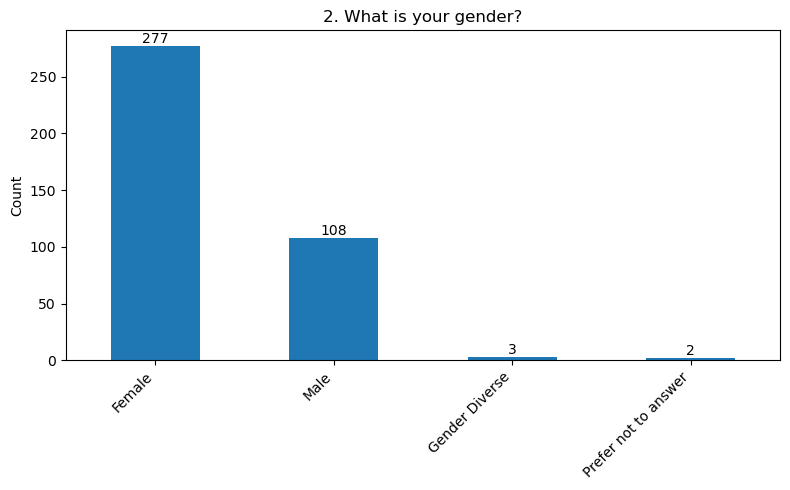

,Category,Count
0,Female,277
1,Male,108
2,Gender Diverse,3
3,Prefer not to answer,2


In [106]:
''' 
columns: 
'Language that survey was completed in'
'Lived Experience (L) or Professional/Researcher (R)'
'NMOSD (N), MOGAD (M), Seronegative (S), Other (O)'
'2. What is your gender?_clean'
'3. What is your ethnicity?_clean' 
'4. In what country do you currently live?_clean' 
'6. How long have you (or your loved one) been living with NMOSD/MOGAD?_clean' 
'7. What age were you (or your loved one) officially diagnosed with NMOSD/MOGAD ?_clean'
'8. What year were you (or your loved one) officially diagnosed with NMOSD/MOGAD?_clean' 
'''
column_to_summarize = '2. What is your gender?_clean'
summarize_column(r1_clean, column_to_summarize)

### DEMOGRAPHIC COMPLETENESS

In [107]:
# define which columns count as "demographic"
demo_cols = [
    '1. Please select all the NMOSD/MOGAD stakeholder communities with which you identify.',
    '2. What is your gender?',
    '3. What is your ethnicity?',
    '4. In what country do you currently live?',
    'NMOSD (N), MOGAD (M), Seronegative (S), Other (O)',
    '5. Which condition are you (or your loved one) impacted by?',
    '6. How long have you (or your loved one) been living with NMOSD/MOGAD?',
    '7. What age were you (or your loved one) officially diagnosed with NMOSD/MOGAD ?',
    '8. What year were you (or your loved one) officially diagnosed with NMOSD/MOGAD?',
    '9. How many NMOSD/MOGAD attacks have you (or your loved one) experienced?',
    '10. What age group do you (or your loved one) fall into?',
    "11. What is your (or your loved one's) primary employment status?",
    '12. What is the highest level of education that you (or your loved one) has completed?',
    '13. In which type of area do you (or your loved one) currently live?',
]

# % of all demographic cells (across all rows x columns) that are non-null
demo_df = r1_clean[demo_cols]
total_cells = demo_df.size
filled_cells = demo_df.notna().sum().sum()
pct_filled_overall = filled_cells / total_cells * 100

print(f"Overall: {filled_cells} / {total_cells} cells filled ({pct_filled_overall:.1f}%)")

Overall: 4142 / 5460 cells filled (75.9%)


In [108]:
# completeness per question 
completeness = pd.DataFrame({
    'n_filled': demo_df.notna().sum(),
    'n_total': len(demo_df),
})
completeness['pct_filled'] = (completeness['n_filled'] / completeness['n_total'] * 100).round(1)
completeness = completeness.sort_values('pct_filled')

print(completeness)

                                                    n_filled  n_total  \
13. In which type of area do you (or your loved...       251      390   
11. What is your (or your loved one's) primary ...       253      390   
12. What is the highest level of education that...       253      390   
10. What age group do you (or your loved one) f...       258      390   
6. How long have you (or your loved one) been l...       262      390   
7. What age were you (or your loved one) offici...       262      390   
8. What year were you (or your loved one) offic...       262      390   
9. How many NMOSD/MOGAD attacks have you (or yo...       262      390   
NMOSD (N), MOGAD (M), Seronegative (S), Other (O)        263      390   
5. Which condition are you (or your loved one) ...       263      390   
3. What is your ethnicity?                               383      390   
1. Please select all the NMOSD/MOGAD stakeholde...       390      390   
2. What is your gender?                            

### DOTPLOT COLUMN COMPARISONS

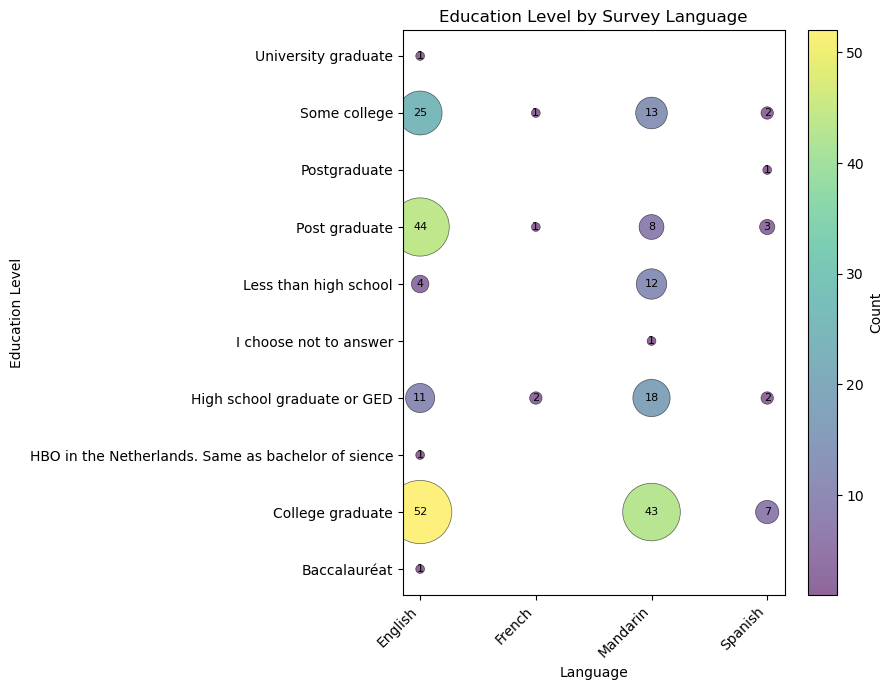

In [109]:
edu_col = '12. What is the highest level of education that you (or your loved one) has completed?'
lang_col = 'Language that survey was completed in'

# build long-format counts
counts = (
    r1_clean.groupby([lang_col, edu_col], dropna=False)
    .size()
    .reset_index(name='count')
)

# map categories to numeric axis positions
edu_levels = sorted(counts[edu_col].dropna().unique())
lang_levels = sorted(counts[lang_col].dropna().unique())

edu_pos = {v: i for i, v in enumerate(edu_levels)}
lang_pos = {v: i for i, v in enumerate(lang_levels)}

counts['x'] = counts[lang_col].map(lang_pos)
counts['y'] = counts[edu_col].map(edu_pos)

fig, ax = plt.subplots(figsize=(9, 7))
scatter = ax.scatter(
    counts['x'], counts['y']
    # scale factor for bubble size
    , s=counts['count'] * 40 
    , alpha=0.6
    , c=counts['count']
    , cmap='viridis'
    , edgecolor='black', linewidth=0.5
)

# annotate each bubble with the actual count
for _, row in counts.iterrows():
    ax.annotate(int(row['count']), (row['x'], row['y']), ha='center', va='center', fontsize=8)

ax.set_xticks(range(len(lang_levels)))
ax.set_xticklabels(lang_levels, rotation=45, ha='right')
ax.set_yticks(range(len(edu_levels)))
ax.set_yticklabels(edu_levels)
ax.set_xlabel('Language')
ax.set_ylabel('Education Level')
ax.set_title('Education Level by Survey Language')

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Count')

plt.tight_layout()
plt.show()

## THEME EXPLORATION

In [110]:
# dataframe:
df_theme_exploration = df1_long.copy()

# widget
id_cols = ['Participants', 'Stakeholder Group']
theme_data_cols = [
    'Language that survey was completed in'
    , 'Lived Experience (L) or Professional/Researcher (R)'
    , 'NMOSD (N), MOGAD (M), Seronegative (S), Other (O)']

dropdown = widgets.Dropdown(
    options=theme_data_cols,
    description="Split by:",
    layout=widgets.Layout(width="300px"),
)
output = widgets.Output(layout=widgets.Layout(
    overflow_y='hidden',
    height='auto'
))

# helper function to render the theme heatmap
def render(change=None):
    col = dropdown.value
    groups = sorted(df_theme_exploration[col].dropna().unique())
    n_groups = len(groups)

    fig = make_subplots(
        rows=n_groups, cols=1,
        subplot_titles=[str(g) for g in groups],
        shared_xaxes=True,
        vertical_spacing=0.08,
    )

    for idx, grp in enumerate(groups):
        subset = df_theme_exploration[df_theme_exploration[col] == grp]
        trace  = heatmap_trace(subset, str(grp))
        trace.update(showscale=(idx == n_groups - 1))
        fig.add_trace(trace, row=idx + 1, col=1)

    fig.update_layout(
        title=dict(text=f'Mean ratings split by: {col}', font=dict(size=14)),
        height=300 * n_groups,
        width = 1400,
        margin=dict(l=60, r=20, t=80, b=20),
        plot_bgcolor='white',
        paper_bgcolor='white',
    )

    for i in range(1, n_groups + 1):
        fig.update_xaxes(
            showticklabels=False,
            showgrid=True,
            gridcolor='rgba(200,200,200,0.5)',
            categoryorder='array',
            categoryarray=df_theme_exploration.sort_values(['theme', 'question'])
                          .drop_duplicates('question')['question'].tolist(),
            row=i, col=1
        )
        fig.update_yaxes(
            showgrid=True,
            gridcolor='rgba(200,200,200,0.5)',
            row=i, col=1
        )

    with output:
        output.clear_output(wait=True)
        fig.show(renderer="notebook")

In [111]:
dropdown.observe(render, names='value')
display(widgets.VBox([dropdown, output]))
render()

## STATS TABLES

### DISPLAY TOP 5 QUESTIONS PER THEME

In [112]:
'''
Likert data: ordinal data collected in surveys to measure altitudes, preferences, or subjective experiences 
- median is a good measure for Likert data 
- ranking anything 7+ as important is also good 
- mean, SD, and IQR are interesting statistics to report 
'''

# get the overall ranks for each theme in r1
overall_ranks = theme_rankings(df1_long)

# display the top 5 in each theme 
top5_by_theme = {
    theme: group.head(5)[
        [
            'theme'
            ,'rank_in_theme'
            ,'question_number'
            ,'question_text'
            ,'n'
            ,'median'
            ,'mean'
            ,'pct_7plus'
        ]
    ]
    for theme, group in overall_ranks.groupby('theme')
}

for theme, df in top5_by_theme.items():
    print(f"\n=== {theme} ===")
    display(df)


=== T1 ===


,theme,rank_in_theme,question_number,question_text,n,median,mean,pct_7plus
9,T1,1,37,Remyelinating treatments,354,9.0,7.791,81.6
4,T1,2,32,Treatment de-escalation and/or discontinuation,354,8.0,7.655,79.1
3,T1,3,31,Treatment switching,355,8.0,7.597,79.4
5,T1,4,33,Immune tolerization,356,8.0,7.553,77.8
0,T1,5,28,Using relapse prevention therapies for acute a...,357,8.0,7.552,79.0



=== T2 ===


,theme,rank_in_theme,question_number,question_text,n,median,mean,pct_7plus
15,T2,1,47,Pain,352,8.0,7.349,71.6
14,T2,2,46,Vision changes,352,8.0,7.330,71.9
18,T2,3,50,Paralysis,346,8.0,7.280,71.1
16,T2,4,48,Spasticity and spasms,348,8.0,7.115,65.5
30,T2,5,62,Bladder and bowel dysfunction,348,8.0,7.106,68.1



=== T3 ===


...

,theme,rank_in_theme,question_number,question_text,n,median,mean,pct_7plus
69,T6,1,27,Guidelines for preventing relapses,359,9.0,7.983,87.5
72,T6,2,74,Accessible treatment,338,9.0,7.917,84.0
73,T6,3,75,Accessible specialists,338,8.0,7.828,82.8
68,T6,4,26,Guidelines for managing acute attacks,359,8.0,7.713,80.2
75,T6,5,86,Emergency care,337,8.0,7.668,78.9



=== T7 ===


,theme,rank_in_theme,question_number,question_text,n,median,mean,pct_7plus
86,T7,1,80,Pediatric patients,328,8.0,7.683,82.9
87,T7,2,81,Pregnant patients,328,8.0,7.659,80.2
85,T7,3,79,Double seronegative patients,329,8.0,7.605,79.3
88,T7,4,82,Patients with delayed diagnosis or misdiagnosis,335,8.0,7.385,72.2
82,T7,5,41,Autoimmune comorbidities,353,8.0,7.241,70.5



=== T8 ===


,theme,rank_in_theme,question_number,question_text,n,median,mean,pct_7plus
96,T8,1,97,Global research collaboration,337,9.0,7.866,85.8
95,T8,2,96,Biorepositories,334,8.0,7.572,78.7
94,T8,3,95,Patient registries,332,8.0,7.554,79.8
93,T8,4,94,Research and clinical trial participation,334,8.0,7.311,73.1
92,T8,5,93,Artificial intelligence/machine learning,331,7.0,6.375,54.1


### SPLIT BY STAKEHOLDER GROUP

In [113]:
# check if the 'Lived Experience (L) or Professional/Researcher (R)' exists in meta_cols
experience_col = 'Lived Experience (L) or Professional/Researcher (R)'

# split rankings by lived experience or researcher
ranks_L = theme_rankings(df1_long[df1_long[experience_col] == 'L'], 'Lived Experience')
ranks_R = theme_rankings(df1_long[df1_long[experience_col] == 'R'], 'Professional/Researcher')

# compare tables for lived experience vs researcher
le_vs_res = compare_rankings(ranks_L, ranks_R, 'L', 'R')
print("\n=== TOP 5 PER THEME: Lived Experience ===")
print(ranks_L.groupby('theme').head(5)[
    ['theme','rank_in_theme', 'question_number', 'question_text','median','mean']].to_string(index=False))
print("\n=== TOP 5 PER THEME: Professionals ===")
print(ranks_R.groupby('theme').head(5)[
    ['theme','rank_in_theme', 'question_number', 'question_text','median','mean']].to_string(index=False))


=== TOP 5 PER THEME: Lived Experience ===
theme  rank_in_theme question_number                                                question_text  median  mean
   T1              1              37                                     Remyelinating treatments     9.0 8.180
   T1              2              32               Treatment de-escalation and/or discontinuation     9.0 7.869
   T1              3              35               CAR (Chimeric Antigen Receptor) T-cell therapy     9.0 7.672
   T1              4              34                                    Stem cell transplantation     9.0 7.564
   T1              5              31                                          Treatment switching     8.0 7.804
   T2              1              50                                                    Paralysis     9.0 7.777
   T2              2              46                                               Vision changes     8.0 7.663
   T2              3              47                         

### SPLIT BY DISEASE

In [114]:
# assign condition column 
cond_col = 'NMOSD (N), MOGAD (M), Seronegative (S), Other (O)'

# empty dict to add condition ranks to 
condition_ranks = {}
for cond in ['N', 'M', 'S', 'O']:
    subset = df1_long[df1_long[cond_col] == cond]
    if len(subset) > 5:
        condition_ranks[cond] = theme_rankings(subset, cond)
        
# show top 5 questions per theme per condition
for theme in condition_ranks['N']['theme'].unique():
    print(f"\n=== {theme} ===")
    
    for cond, label in [('N','NMOSD'), ('M','MOGAD'), ('S','Seronegative')]:
        if cond in condition_ranks:
            df = condition_ranks[cond]
            subset = df[df['theme'] == theme].head(5)
            
            subset = subset.copy()
            subset['condition'] = label
            
            print(f"\n{label}")
            print(subset[
                ['question_number','question_text','rank_in_theme','median','mean','pct_7plus']
            ].to_string(index=False))


=== T1 ===

NMOSD
question_number                                  question_text  rank_in_theme  median  mean  pct_7plus
             37                       Remyelinating treatments              1     9.0 8.176       87.3
             35 CAR (Chimeric Antigen Receptor) T-cell therapy              2     9.0 7.820       81.3
             34                      Stem cell transplantation              3     9.0 7.626       77.7
             32 Treatment de-escalation and/or discontinuation              4     8.5 7.729       82.9
             31                            Treatment switching              5     8.0 7.709       81.6

MOGAD
question_number                                        question_text  rank_in_theme  median  mean  pct_7plus
             29                  Monotherapy vs. combination therapy              1     9.0 8.279       89.7
             37                             Remyelinating treatments              2     9.0 8.277       87.7
             32       Treatme

### MANN-WHITNEY U (L VS R, PER QUESTION)
DO RATING DIFFER BETWEEN GROUPS

In [115]:
# empty list for MW test results 
mw_results = []

# loop over columns 
for (theme, qnum, qtext), grp in df1_long.dropna(subset=['rating']).groupby(
        ['theme', 'question_number', 'question_text']):
    
    # split by experience group 
    group_L = grp[grp[experience_col] == 'L']['rating'].dropna()
    group_R = grp[grp[experience_col] == 'R']['rating'].dropna()

    # contingecy (skip small sample sizes)
    if len(group_L) < 3 or len(group_R) < 3:
        continue

    # run MW-U test with two-sided - test for any difference not just L > R or R > L
    U, p = stats.mannwhitneyu(group_L, group_R, alternative='two-sided')

    # compute effect size using rank-biserial correlation - converts U to an effect size from -1 to 1 (direction & strength of difference)
    n1, n2 = len(group_L), len(group_R)
    r_rb = 1 - (2 * U) / (n1 * n2)

    # store results 
    mw_results.append({
        'theme': theme
        , 'question_number': qnum
        , 'question_text': qtext
        , 'median_L': group_L.median()
        , 'median_R': group_R.median()
        , 'n_L': n1
        , 'n_R': n2
        , 'U': U
        , 'p_raw': p
        , 'effect_r': round(r_rb, 3)
    })

# convert list to dataframe 
mw_df = pd.DataFrame(mw_results)

# adjust p-values - apply Benjamini-Hochberg FDR correction
_, mw_df['p_adjusted'], _, _ = multipletests(mw_df['p_raw'], method='fdr_bh')

# flag significant reslts, sort by adjusted P per theme
mw_df['significant'] = mw_df['p_adjusted'] < 0.05
mw_df = mw_df.sort_values(['theme', 'p_adjusted'])

print(f"\n=== L vs R: Significantly different items (FDR<0.05): {mw_df['significant'].sum()} ===")
print(mw_df[mw_df['significant']][
    ['theme', 'question_number', 'question_text', 'median_L', 'median_R' ,'p_adjusted', 'effect_r']
].to_string(index=False))


=== L vs R: Significantly different items (FDR<0.05): 81 ===
theme question_number                                           question_text  median_L  median_R   p_adjusted  effect_r
   T1              34                               Stem cell transplantation       9.0       6.0 3.385533e-13    -0.491
   T1              37                                Remyelinating treatments       9.0       7.0 5.003050e-12    -0.441
   T1              29                     Monotherapy vs. combination therapy       8.0       7.0 2.319911e-08    -0.372
   T1              35          CAR (Chimeric Antigen Receptor) T-cell therapy       9.0       7.0 1.468295e-06    -0.318
   T1              44                                   Hypogammaglobulinemia       8.0       6.5 3.720406e-06    -0.318
   T1              36                              Other cell-based therapies       8.0       7.0 4.765666e-05    -0.278
   T1              33                                     Immune tolerization       8.0    

### KRUSKAL-WALLIS (ACROSS N/M/O DISEASE STATES)
NON-PARAMETRIC ANOVA (3 OR MORE INDEPENDENT GROUPS): DO GROUPS COME FROM THE SAME DISTRIBUTION

In [116]:
# uses ranks of values instead of means so it works well when you have ordinal data with non-normal distributions

# empty list for KW results 
kw_results = []

# loop over columns 
for (theme, qnum, qtext), grp in df1_long.dropna(subset=['rating']).groupby(
        ['theme', 'question_number', 'question_text']):
    # build groups for each condition - split by value in column and turn each into an aray 
    groups = [g['rating'].dropna().values
              for _, g in grp.groupby(cond_col)
              if len(g['rating'].dropna()) >= 3]
    # filter small groups out 
    if len(groups) < 2:
        continue

    # run Kruskal–Wallis test: H-stat measures how different group medians are, p-value is the probability that the differences are due to chance 
    H, p = stats.kruskal(*groups)
    # store results 
    kw_results.append({
        'theme': theme
        , 'question_number': qnum
        , 'question_text': qtext
        , 'H': round(H, 3)
        , 'p_raw': p
    })

# convert list to dataframe 
kw_df = pd.DataFrame(kw_results)

# adjust p-values - apply Benjamini-Hochberg FDR correction
_, kw_df['p_adjusted'], _, _ = multipletests(kw_df['p_raw'], method='fdr_bh')

# flag significant reslts, sort by adjusted P per theme
kw_df['significant'] = kw_df['p_adjusted'] < 0.05
kw_df = kw_df.sort_values(['theme', 'p_adjusted'])

print(f"\n=== Condition differences (N/M/S/O): Significant items: {kw_df['significant'].sum()} ===")
print(kw_df[kw_df['significant']][
    ['theme','question_text','H','p_adjusted']
].to_string(index=False))


=== Condition differences (N/M/S/O): Significant items: 1 ===
theme                question_text      H  p_adjusted
   T7 Double seronegative patients 17.929    0.044119


In [117]:
posthoc_results = []

# only worth running this on items KW already flagged as significant
sig_items = kw_df[kw_df['significant']][['theme', 'question_number', 'question_text']]

for _, row in sig_items.iterrows():
    grp = df1_long[
        (df1_long['theme'] == row['theme']) &
        (df1_long['question_number'] == row['question_number'])
    ].dropna(subset=['rating'])

    valid_groups = {
        name: g['rating'].dropna().values
        for name, g in grp.groupby(cond_col)
        if len(g['rating'].dropna()) >= 3
    }

    pair_results = []
    for g1, g2 in combinations(valid_groups.keys(), 2):
        a, b = valid_groups[g1], valid_groups[g2]
        U, p = stats.mannwhitneyu(a, b, alternative='two-sided')
        r_rb = 1 - (2 * U) / (len(a) * len(b))
        pair_results.append({
            'theme': row['theme'], 'question_number': row['question_number'],
            'question_text': row['question_text'],
            'group_1': g1, 'group_2': g2,
            'median_1': np.median(a), 'median_2': np.median(b),
            'median_diff': np.median(a) - np.median(b),
            'p_raw': p, 'effect_r': round(r_rb, 3)
        })

    # Holm correction across just this item's pairwise comparisons
    pair_df = pd.DataFrame(pair_results)
    _, pair_df['p_holm'], _, _ = multipletests(pair_df['p_raw'], method='holm')
    pair_df['significant'] = pair_df['p_holm'] < 0.05
    posthoc_results.append(pair_df)

posthoc_df = pd.concat(posthoc_results, ignore_index=True).sort_values(['question_number', 'p_holm'])

print(f"\n=== Significant pairwise differences within KW-flagged items ===")
print(posthoc_df[posthoc_df['significant']][
    ['theme', 'question_text', 'group_1', 'group_2', 'median_1', 'median_2', 'median_diff', 'p_holm', 'effect_r']
].to_string(index=False))


=== Significant pairwise differences within KW-flagged items ===
theme                question_text group_1 group_2  median_1  median_2  median_diff   p_holm  effect_r
   T7 Double seronegative patients       N       S       8.0       9.0         -1.0 0.001189     0.437
   T7 Double seronegative patients       M       S       8.0       9.0         -1.0 0.007415     0.401


### IMPORTANCE (BRING TO ROUND 3?)

#### CRITERIA & SHORTLIST

In [118]:
'''
Criteria: 
1. median (mode?) ≥ 7 overall 
2. % answers over 7 ≥ 70%
3. IQR ≤ 3 (because this means that there is some level of consensus)
4. flagged if lived experience vs research has significant differences 
5. flag if the condition groups have significant differences 
'''

'\nCriteria: \n1. median (mode?) ≥ 7 overall \n2. % answers over 7 ≥ 70%\n3. IQR ≤ 3 (because this means that there is some level of consensus)\n4. flagged if lived experience vs research has significant differences \n5. flag if the condition groups have significant differences \n'

In [119]:
# flag conditions (pull from overall ranks)
shortlist = overall_ranks[
    (overall_ranks['median'] >= 7) &
    (overall_ranks['pct_7plus'] >= 70) &
    (overall_ranks['iqr'] <= 3)
].copy()

# merge in group difference flags
shortlist = shortlist.merge(
    mw_df[['theme','question_number','significant']].rename(columns={'significant':'L_vs_R_diff'}),
    on=['theme','question_number'], how='left'
).merge(
    kw_df[['theme','question_number','significant']].rename(columns={'significant':'condition_diff'}),
    on=['theme','question_number'], how='left'
)

print(f"\n=== ROUND 3 SHORTLIST: {len(shortlist)} questions meet criteria ===")
print(shortlist[['theme'
                 , 'rank_in_theme'
                 , 'question_number'
                 , 'question_text'
                 , 'n'
                 , 'median'
                 , 'pct_7plus'
                 , 'iqr'
                 , 'L_vs_R_diff' 
                 , 'condition_diff'
                 ]].to_string(index=False))


=== ROUND 3 SHORTLIST: 48 questions meet criteria ===
theme  rank_in_theme question_number                                                question_text   n  median  pct_7plus  iqr  L_vs_R_diff  condition_diff
   T1              1              37                                     Remyelinating treatments 354     9.0       81.6 2.00         True           False
   T1              2              32               Treatment de-escalation and/or discontinuation 354     8.0       79.1 2.00         True           False
   T1              3              31                                          Treatment switching 355     8.0       79.4 2.00         True           False
   T1              4              33                                          Immune tolerization 356     8.0       77.8 2.00         True           False
   T1              5              28         Using relapse prevention therapies for acute attacks 357     8.0       79.0 2.00        False           False
   T1          

In [120]:
# reorder shortlist 
shortlist = shortlist[[
    'rank_in_theme'
    , 'theme'
    , 'question_number'
    , 'question_text'
    , 'median'
    , 'pct_7plus'
    , 'iqr'
    , 'n'
    , 'mean'
    , 'sd'
    , 'L_vs_R_diff'
    , 'condition_diff'
]]

#### SIGNIFICANT DIFFERENCES BEWEEN GROUPS

In [121]:
# data to use 
df_overall_ranks = df1_long.copy()

# define lived experience and condition columns 
le_col = 'Lived Experience (L) or Professional/Researcher (R)'
cond_col = 'NMOSD (N), MOGAD (M), Seronegative (S), Other (O)'

In [122]:
# median/mean % difference between L and R
le_summary = (
    df_overall_ranks.dropna(subset=['rating'])
    .groupby(['theme', 'question_number', 'question_text', le_col])['rating']
    .median()
    .unstack(le_col)
    .reset_index()
)

# % difference: positive = L rated higher, negative = R rated higher
le_summary['L_vs_R_pct_diff'] = (
    (le_summary['L'] - le_summary['R']) / le_summary['R'] * 100
).round(1)

le_summary['L_vs_R_narrative'] = le_summary.apply(lambda row:
    f"LE {abs(row['L_vs_R_pct_diff']):.1f}% > R"
    if row['L_vs_R_pct_diff'] > 0
    else f"R {abs(row['L_vs_R_pct_diff']):.1f}% > LE"
    if row['L_vs_R_pct_diff'] < 0
    else 'No difference'
    if pd.notna(row['L_vs_R_pct_diff'])
    else 'Insufficient data',
    axis=1
)

In [123]:
# median/mean % difference between conditions
# create a new column that maps conditions to the comparison groups, excluding Other
df1_long['condition_group'] = df1_long[cond_col].map({
    'N': 'NMOSD',
    'S': 'NMOSD',
    'M': 'MOGAD',
    'O': None
})

# median % difference between NMOSD (N+S) and MOGAD (M), dropna used to drop O 
cond_summary = (
    df1_long.dropna(subset=['rating'])
    .dropna(subset=['condition_group'])
    .groupby(['theme', 'question_number', 'question_text', 'condition_group'])['rating']
    .median()
    .unstack('condition_group')
    .reset_index()
)

def condition_narrative(row):
    vals = {c: row[c] for c in ['NMOSD', 'MOGAD'] if c in row and pd.notna(row[c])}
    if len(vals) < 2:
        return 'Insufficient data'
    highest = max(vals, key=vals.get)
    lowest  = min(vals, key=vals.get)
    if vals[highest] == vals[lowest]:
        return 'No difference'
    pct_diff = ((vals[highest] - vals[lowest]) / vals[lowest] * 100)
    return f"{highest} {pct_diff:.1f}% > {lowest}"

cond_summary['condition_narrative'] = cond_summary.apply(condition_narrative, axis=1)

In [124]:
# mean rating by L/R group for each question
le_mean_summary = (
    df_overall_ranks.dropna(subset=['rating'])
    .groupby(['theme', 'question_number', 'question_text', le_col])['rating']
    .mean()
    .unstack(le_col)
    .reset_index()
    .rename(columns={
        'L': 'L_mean',
        'R': 'R_mean'
    })
)

In [125]:
# merge in group difference flags to overall ratings
overall_ranks = overall_ranks.merge(
    mw_df[['theme','question_number','significant']].rename(columns={'significant':'L_vs_R_diff'}),
    on=['theme','question_number'], how='left'
).merge(
    kw_df[['theme','question_number','significant']].rename(columns={'significant':'condition_diff'}),
    on=['theme','question_number'], how='left'
)

# merge the narrative columns in 
overall_ranks = overall_ranks.merge(
    le_summary[['theme', 'question_number', 'L_vs_R_pct_diff', 'L_vs_R_narrative']],
    on=['theme', 'question_number'], how='left'
).merge(
    cond_summary[['theme', 'question_number', 'condition_narrative']],
    on=['theme', 'question_number'], how='left'
)

# merge mean by L/R group 
overall_ranks = overall_ranks.merge(
    le_mean_summary[['theme', 'question_number', 'L_mean', 'R_mean']],
    on=['theme', 'question_number'],
    how='left'
)

# add a theme_description column to the full dataset
theme_description_tier_ranges = {
    'Treating attacks and preventing relapses': list(range(28, 40)) + list(range(43, 45))
    , 'Managing symptoms': list(range(46, 65))
    , 'Biomarkers, testing & clinical course': list(range(16, 19)) + list(range(20, 26)) + [40, 42]
    , 'Understanding disease mechanisms': list(range(1, 16))
    , 'Impacts on quality of life': list(range(65, 73))
    , 'Improving healthcare delivery': [19, 26, 27, 45] + list(range(73, 77)) + list(range(86, 93))
    , 'Addressing diverse patient needs': [41] + list(range(77, 86))
    , 'Enabling further research': list(range(93, 98))
}

# helper function to attach text column to dataframe
def get_theme_description(qnum):
    if pd.isna(qnum):
        return None

    qnum = int(qnum)

    for theme, rng in theme_description_tier_ranges.items():
        if qnum in rng:
            return theme

    return None

# apply theme_description 
overall_ranks['theme_description'] = (
    overall_ranks['question_number']
    .apply(get_theme_description)
)

# add empty 'R3?' column 
overall_ranks['R3?'] = None

# reorder overall_ranks rankings 
overall_ranks = overall_ranks[[
    'theme'
    , 'theme_description'
    , 'question_number'
    , 'question_text'
    , 'R3?'
    , 'rank_in_theme'
    , 'n'
    , 'mean'
    , 'median'
    , 'sd'
    , 'iqr'
    , 'pct_7plus'
    , 'L_vs_R_diff'
    , 'L_vs_R_narrative'
    , 'L_mean'
    , 'R_mean'
    , 'condition_diff'
    , 'condition_narrative'
]]

## SAVE DATAFRAMES

In [ ]:
# # export stats tables
# shortlist.to_csv('/path/to/file', index=False)
# overall_ranks.to_csv('/path/to/file', index=False)
# mw_df.to_csv('/path/to/file', index=False)
# kw_df.to_csv('/path/to/file', index=False)

In [ ]:
# save df1_long to csv file to use in other scripts
# df1_long.to_csv('/path/to/file', index=False)

In [ ]:
# save r1_clean to csv file to use in UMAP Clustering script
# r1_clean.to_csv('/path/to/file', index=False)

In [ ]:
# save r2 after running it through the clean function 
# r2.to_csv('/path/to/file', index=False)

## SCATTERPLOTS: PATIENTS VS CLINICIANS

### THEME DESCRIPTIONS

In [130]:
# add in theme descriptions to long dataframe 
scatterplot_df = df1_long.copy()

# theme description map 
theme_description_tier_ranges = {
    'Treating attacks and preventing relapses': list(range(28, 40)) + list(range(43, 45))
    , 'Managing symptoms': list(range(46, 65))
    , 'Biomarkers, testing & clinical course': list(range(16, 19)) + list(range(20, 26)) + [40, 42]
    , 'Understanding disease mechanisms': list(range(1, 16))
    , 'Impacts on quality of life': list(range(65, 73))
    , 'Improving healthcare delivery': [19, 26, 27, 45] + list(range(73, 77)) + list(range(86, 93))
    , 'Addressing diverse patient needs': [41] + list(range(77, 86))
    , 'Enabling further research': list(range(93, 98))
}

# invert to flat dictinary where question_number maps to description
qnum_to_description = {
    qnum: desc
    for desc, qrange in theme_description_tier_ranges.items()
    for qnum in qrange
}

# convert question number column to numeric 
scatterplot_df['question_number'] = scatterplot_df['question_number'].astype(str).str.strip().astype(int)

# add column to scatterplot_df
scatterplot_df['theme_description'] = scatterplot_df['question_number'].map(qnum_to_description)

### PATIENTS VS CLINICIANS PLOT

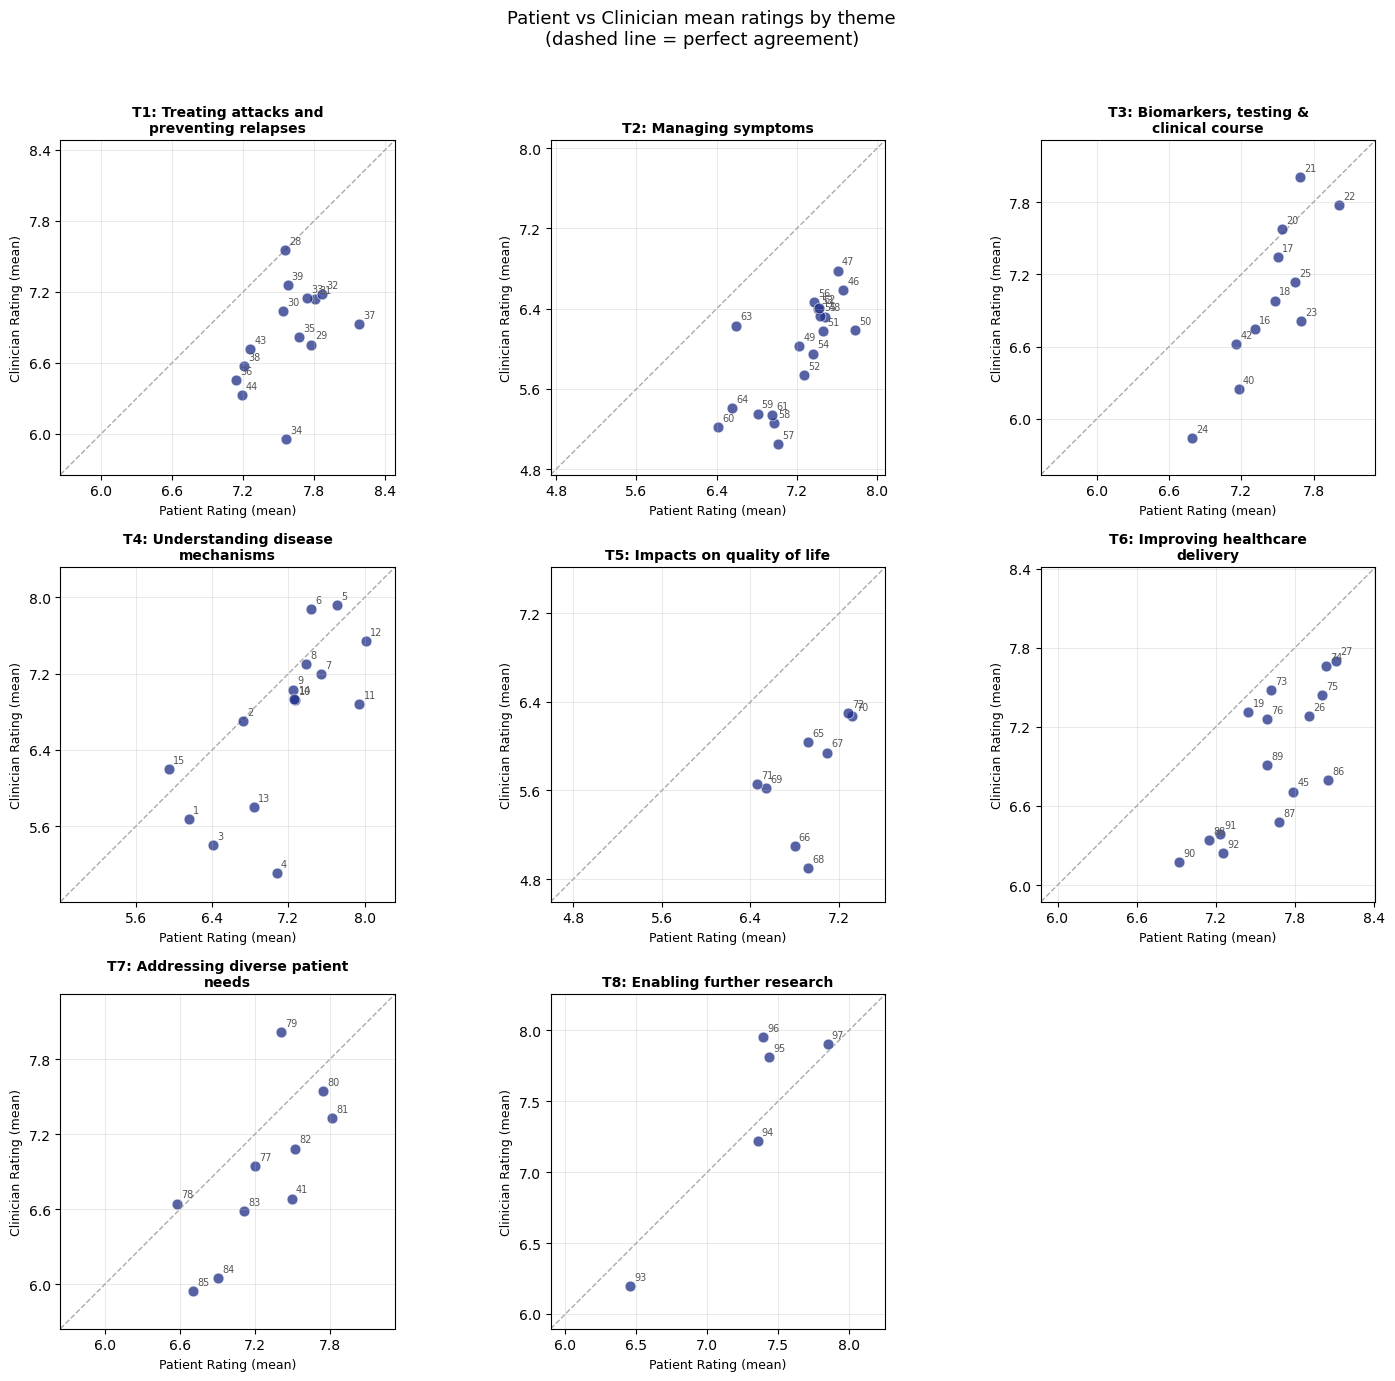

In [131]:
df_p_vs_c = scatterplot_df.copy()

# get mean ratings for rows that have the same values in this set:
group_means = (
    df_p_vs_c.groupby(['question_number'
                , 'question_text'
                , 'theme'
                , 'theme_description'
                , 'Lived Experience (L) or Professional/Researcher (R)'
    ])['rating']
    .mean()
    .reset_index()
)

# separate patient and clinician groups 
patients  = group_means[group_means['Lived Experience (L) or Professional/Researcher (R)'] == 'L']
clinicians = group_means[group_means['Lived Experience (L) or Professional/Researcher (R)'] == 'R']

# merge the two group, but add a suffix for lived experience or researcher 
merged = patients.merge(
    clinicians,
    on=['question_number', 'question_text', 'theme', 'theme_description'],
    suffixes=("_L", "_R")
)

# keep themes in order
theme_order = list(theme_description_tier_ranges.keys())
themes = [t for t in theme_order if t in merged['theme_description'].unique()]

# map the theme description to the category 
theme_label_map = {
    'Treating attacks and preventing relapses': 'T1'
    , 'Managing symptoms': 'T2'
    , 'Biomarkers, testing & clinical course': 'T3'
    , 'Understanding disease mechanisms': 'T4'
    , 'Impacts on quality of life': 'T5'
    , 'Improving healthcare delivery': 'T6'
    , 'Addressing diverse patient needs': 'T7'
    , 'Enabling further research': 'T8'
}

# assign number of rows and columns for plot
ncols = 3
nrows = -(-len(themes) // ncols)

# assign figure size and axes 
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows))
axes = axes.flatten()

# loop through axes and themes to create a subplot for each theme  
for ax, theme_desc in zip(axes, themes):
    # filter data for the current theme
    data = merged[merged['theme_description'] == theme_desc]
    # define x and y
    x = data['rating_L']
    y = data['rating_R']

    # create scatter plot 
    ax.scatter(x, y, alpha=0.75, s=60, color="#1E2E86", edgecolors='white', linewidths=0.5)

    # label each point 
    for _, row in data.iterrows():
        # small text, align text on the left/bottom, and move the label 3 pixels up and 3 over 
        ax.annotate(
            str(int(row['question_number'])),
            (row['rating_L'], row['rating_R']),
            fontsize=7, ha='left', va='bottom',
            xytext=(3, 3), textcoords='offset points', color='#555'
        )

    # add extra space around data, find min/max values to get the highest and lowest across both axes 
    pad = 0.3
    lo = min(x.min(), y.min()) - pad
    hi = max(x.max(), y.max()) + pad

    # reference line (y=x)
    ax.plot([lo, hi], [lo, hi], color='#aaa', linewidth=1, linestyle='--', zorder=0)
    # axis limits 
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect('equal')

    # wrap long titles so they don't overflow
    wrapped = textwrap.fill(theme_desc, width=30)

    label = theme_label_map.get(theme_desc, "")
    wrapped = textwrap.fill(theme_desc, width=28)
    ax.set_title(f"{label}: {wrapped}", fontsize=10, fontweight='bold')

    ax.set_xlabel('Patient Rating (mean)', fontsize=9)
    ax.set_ylabel('Clinician Rating (mean)', fontsize=9)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=False, nbins=5))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=False, nbins=5))
    ax.grid(True, linewidth=0.4, alpha=0.5)

for ax in axes[len(themes):]:
    ax.set_visible(False)

fig.suptitle('Patient vs Clinician mean ratings by theme\n(dashed line = perfect agreement)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### INDIVIDUAL PLOTS

In [132]:
theme_order = list(theme_description_tier_ranges.keys())
themes = [t for t in theme_order if t in merged['theme_description'].unique()]

# for theme_desc in themes:
#     data = merged[merged['theme_description'] == theme_desc]
#     x = data['rating_L']
#     y = data['rating_R']

#     fig, ax = plt.subplots(figsize=(5, 5))

#     ax.scatter(x, y, alpha=0.75, s=60, color="#4C72B0", edgecolors="white", linewidths=0.5)

#     for _, row in data.iterrows():
#         ax.annotate(
#             str(int(row['question_number'])),
#             (row['rating_L'], row['rating_R']),
#             fontsize=7, ha='left', va='bottom',
#             xytext=(3, 3), textcoords='offset points', color='#555'
#         )

#     pad = 0.3
#     lo = min(x.min(), y.min()) - pad
#     hi = max(x.max(), y.max()) + pad
#     ax.plot([lo, hi], [lo, hi], color='#aaa', linewidth=1, linestyle='--', zorder=0)
#     ax.set_xlim(lo, hi)
#     ax.set_ylim(lo, hi)
#     ax.set_aspect('equal')

#     label = theme_label_map.get(theme_desc, '')
#     wrapped = textwrap.fill(theme_desc, width=35)
#     ax.set_title(f"{label}: {wrapped}", fontsize=11, fontweight="bold")
#     ax.set_xlabel('Patients / Lived Experience (mean rating)', fontsize=9)
#     ax.set_ylabel('Clinicians / Researchers (mean rating)', fontsize=9)
#     ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=False, nbins=5))
#     ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=False, nbins=5))
#     ax.grid(True, linewidth=0.4, alpha=0.5)

    # plt.tight_layout()
    # plt.show()

### MANDARIN VS ENGLISH

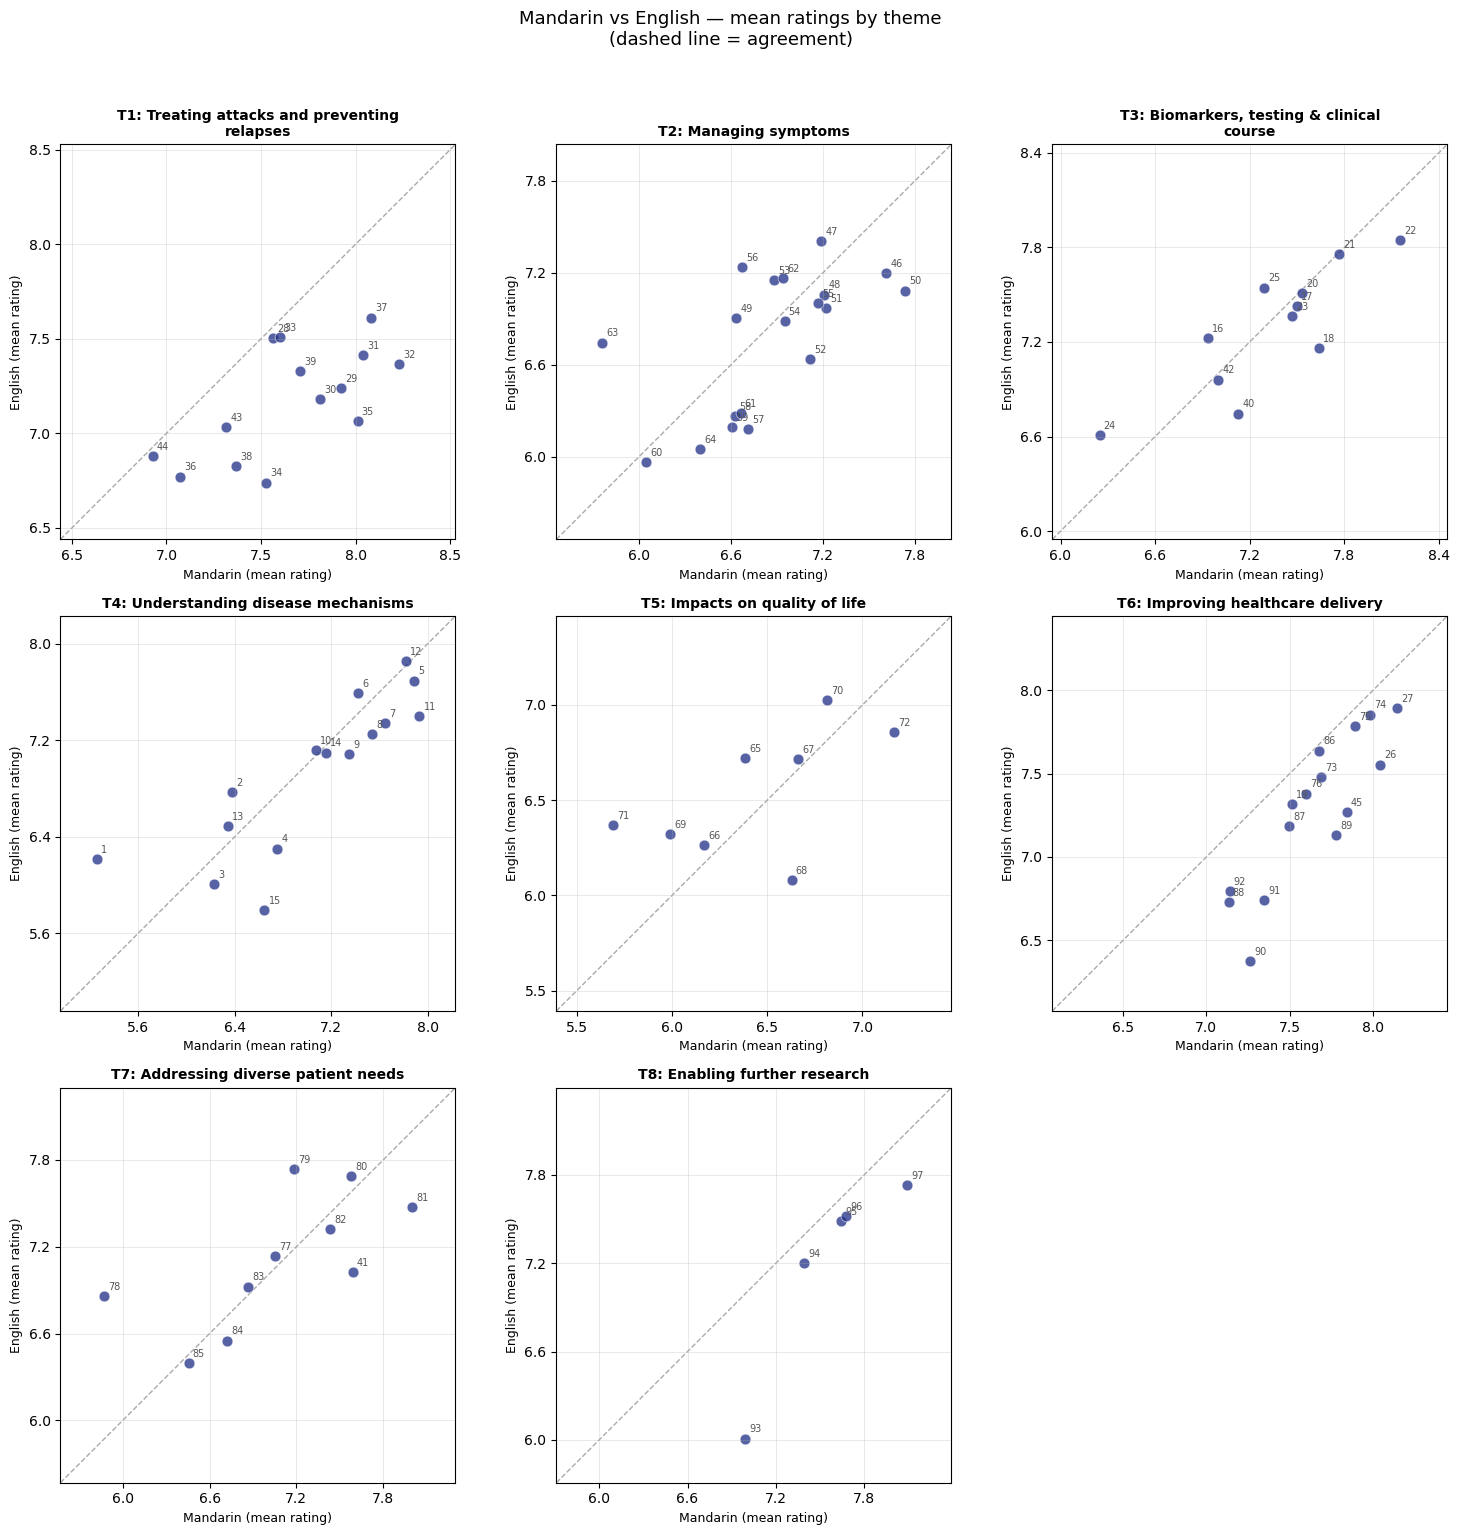

In [133]:
language_df = scatterplot_df.copy()

# Mandarin vs English
plot_column_comparison(
    language_df,
    comparison_col='Language that survey was completed in',
    group_a='Mandarin',
    group_b_list=['English'],
    label_a='Mandarin',
    label_b='English',
    theme_description_tier_ranges=theme_description_tier_ranges,
    theme_label_map=theme_label_map,
)

### MANDARIN VS ENGLISH: PATIENTS ONLY

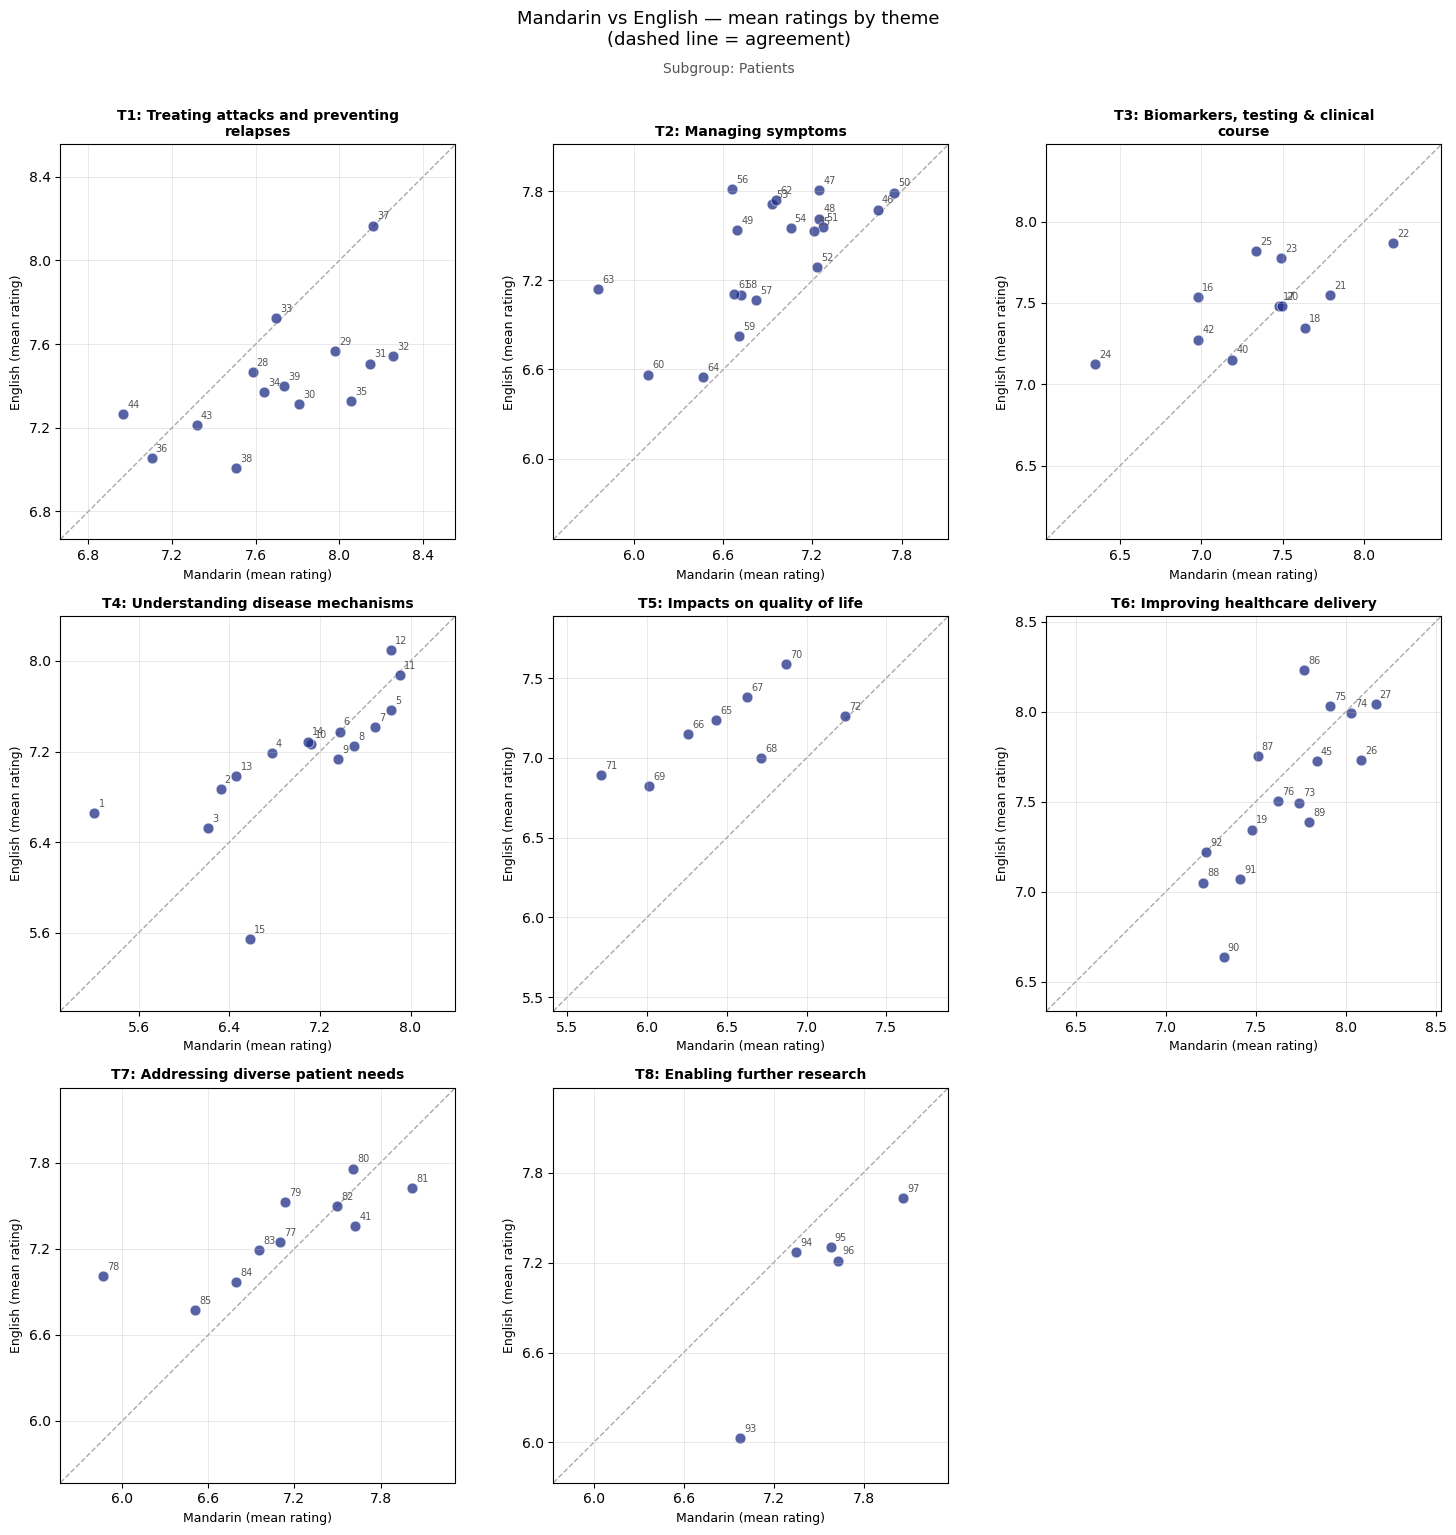

In [134]:
LE_df = language_df[language_df['Lived Experience (L) or Professional/Researcher (R)'] == 'L']

# Mandarin vs English
plot_column_comparison(
    LE_df,
    comparison_col='Language that survey was completed in',
    group_a='Mandarin',
    group_b_list=['English'],
    label_a='Mandarin',
    label_b='English',
    theme_description_tier_ranges=theme_description_tier_ranges,
    theme_label_map=theme_label_map,
    secondary_title='Subgroup: Patients'
)

### SPANISH VS FRENCH

In [135]:
# language_df = scatterplot_df.copy()

# # Spanish vs French
# plot_column_comparison(
#     language_df,
#     comparison_col='Language that survey was completed in',
#     group_a='Spanish',
#     group_b_list=['French'],
#     label_a='Spanish',
#     label_b='French',
#     theme_description_tier_ranges=theme_description_tier_ranges,
#     theme_label_map=theme_label_map,
# )

### NMOSD VS MOGAD

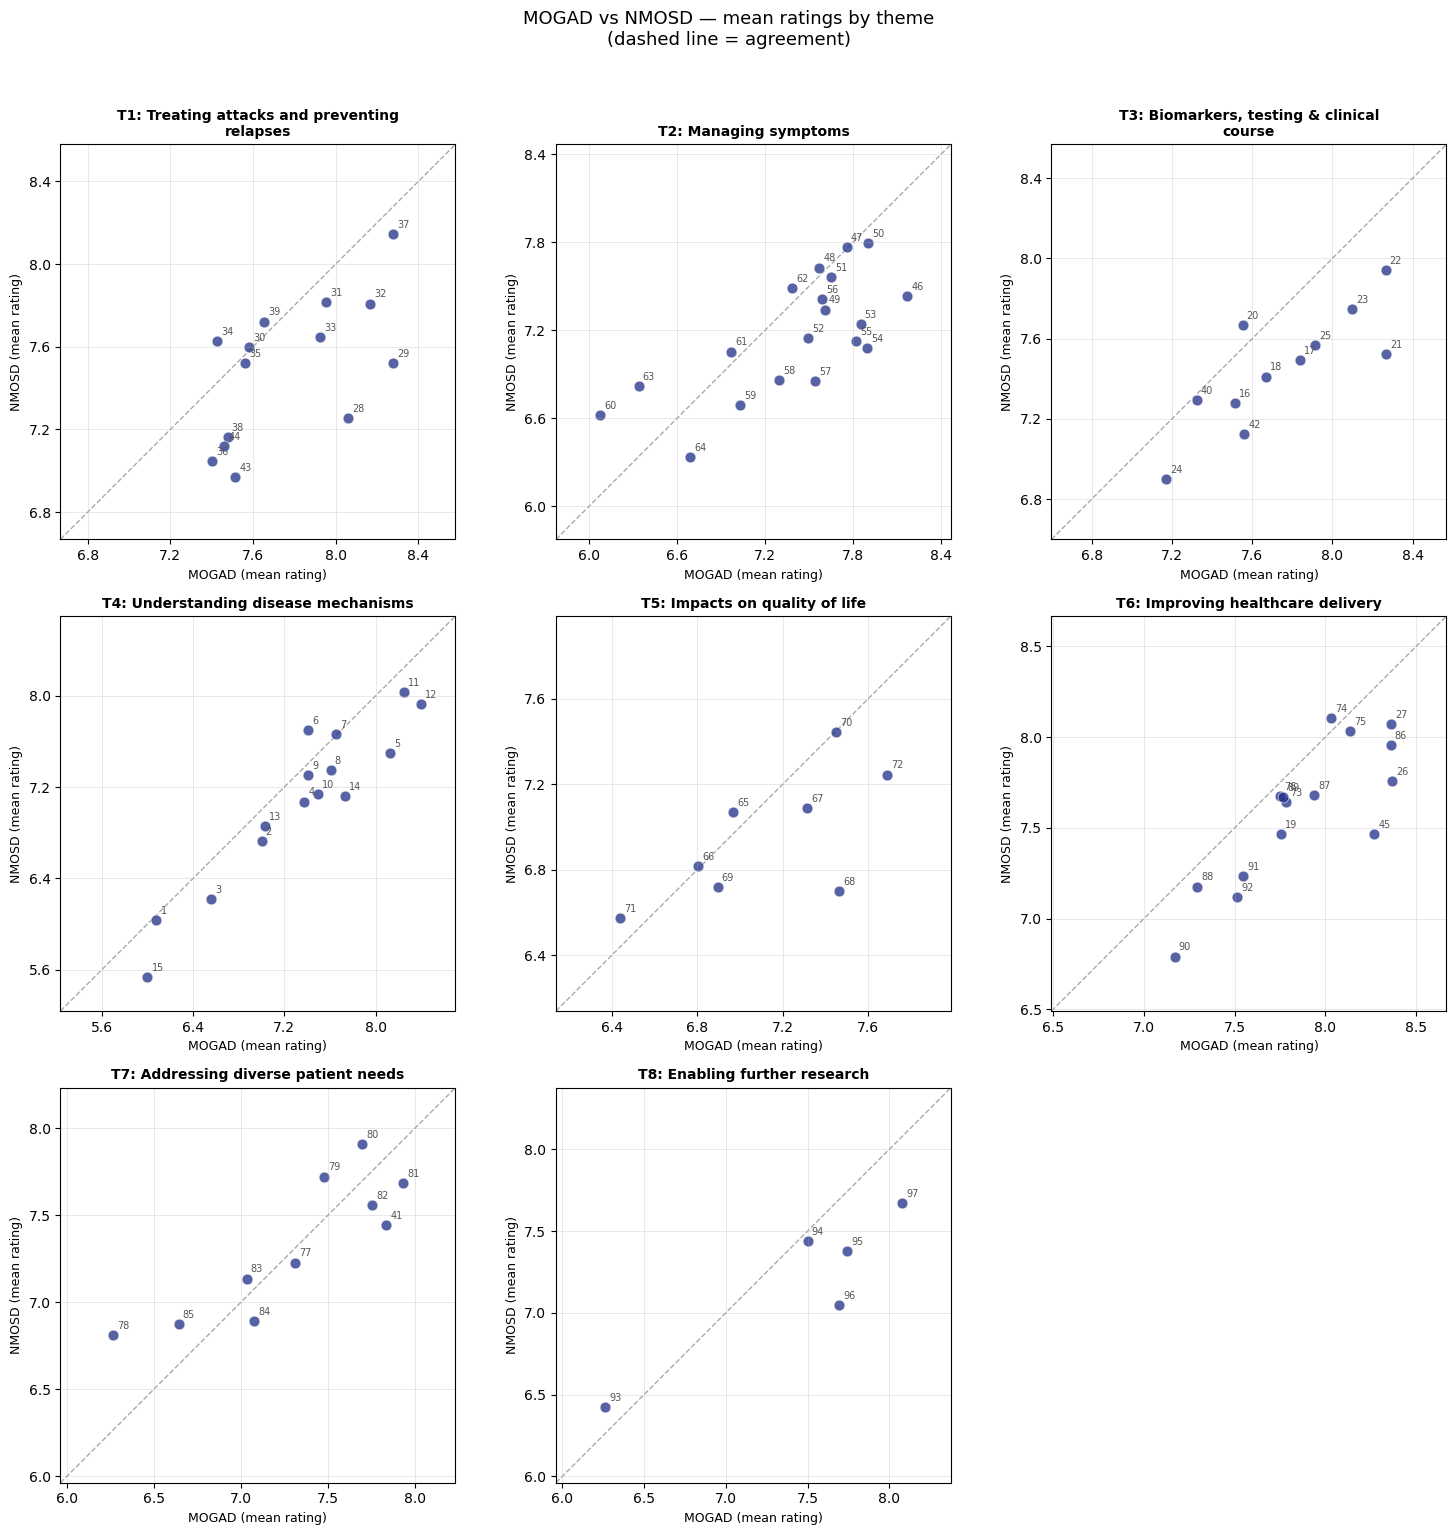

In [136]:
disease_state_df = scatterplot_df.copy()

# disease state
plot_column_comparison(
    disease_state_df,
    comparison_col='NMOSD (N), MOGAD (M), Seronegative (S), Other (O)',
    group_a='M',
    group_b_list=['S', 'N'],
    label_a='MOGAD',
    label_b='NMOSD',
    theme_description_tier_ranges=theme_description_tier_ranges,
    theme_label_map=theme_label_map,
)

### SCATTERPLOT BY GROUP AVERAGES (NORMALIZED)
From my understanding, normalizing in this way would remove a systemic bias (like where patients tend to rate things higher than clinicians) while preserving any patterns that underlie their ratings. But this also means that the diagonal line isn't perfect agreement, I think it would be more like "they agreed on this item but in a relative capacity to their overall ranking pattern tendencies" <br>
Also, I calculated this as an overall gap, but I am not sure if it would be better to do it per theme? 

In [137]:
# use long format data to get group means per question
q_means = (
    df1_long.dropna(subset=['rating'])
    .groupby(['theme', 'question_number', 'question_text', experience_col])['rating']
    .mean()
    .reset_index()
    .pivot_table(index=['theme', 'question_number', 'question_text'],
                 columns=experience_col, values='rating')
    .reset_index()
)

# get the overall gap between groups (average across all questions)
overall_gap = (q_means['L'] - q_means['R']).mean()
print(f'Overall average patient-clinician gap: {overall_gap:.3f} points (using the 1-9 scale)')

Overall average patient-clinician gap: 0.701 points (using the 1-9 scale)


In [138]:
# normalize (subtract the constant from patient scores)
q_means['L_normalized'] = q_means['L'] - overall_gap

# rescale (1-9 to 0-100)
def rescale_1_9_to_100(x):
    return (x - 1) / 8 * 100

# raw values 
q_means['L_scaled'] = rescale_1_9_to_100(q_means['L'])
# normalized values 
q_means['L_norm_scaled'] = rescale_1_9_to_100(q_means['L_normalized'])
q_means['R_scaled'] = rescale_1_9_to_100(q_means['R'])

# map theme labels so they can be used as the titles for each plot
q_means['theme_display'] = q_means['theme']

Text(0.5, 1.01, 'Patient vs. Clinician Ratings by Theme, Normalized\n(~0.70-point patient bias accounted for, and 1-9 scale rescaled to 0-100)')

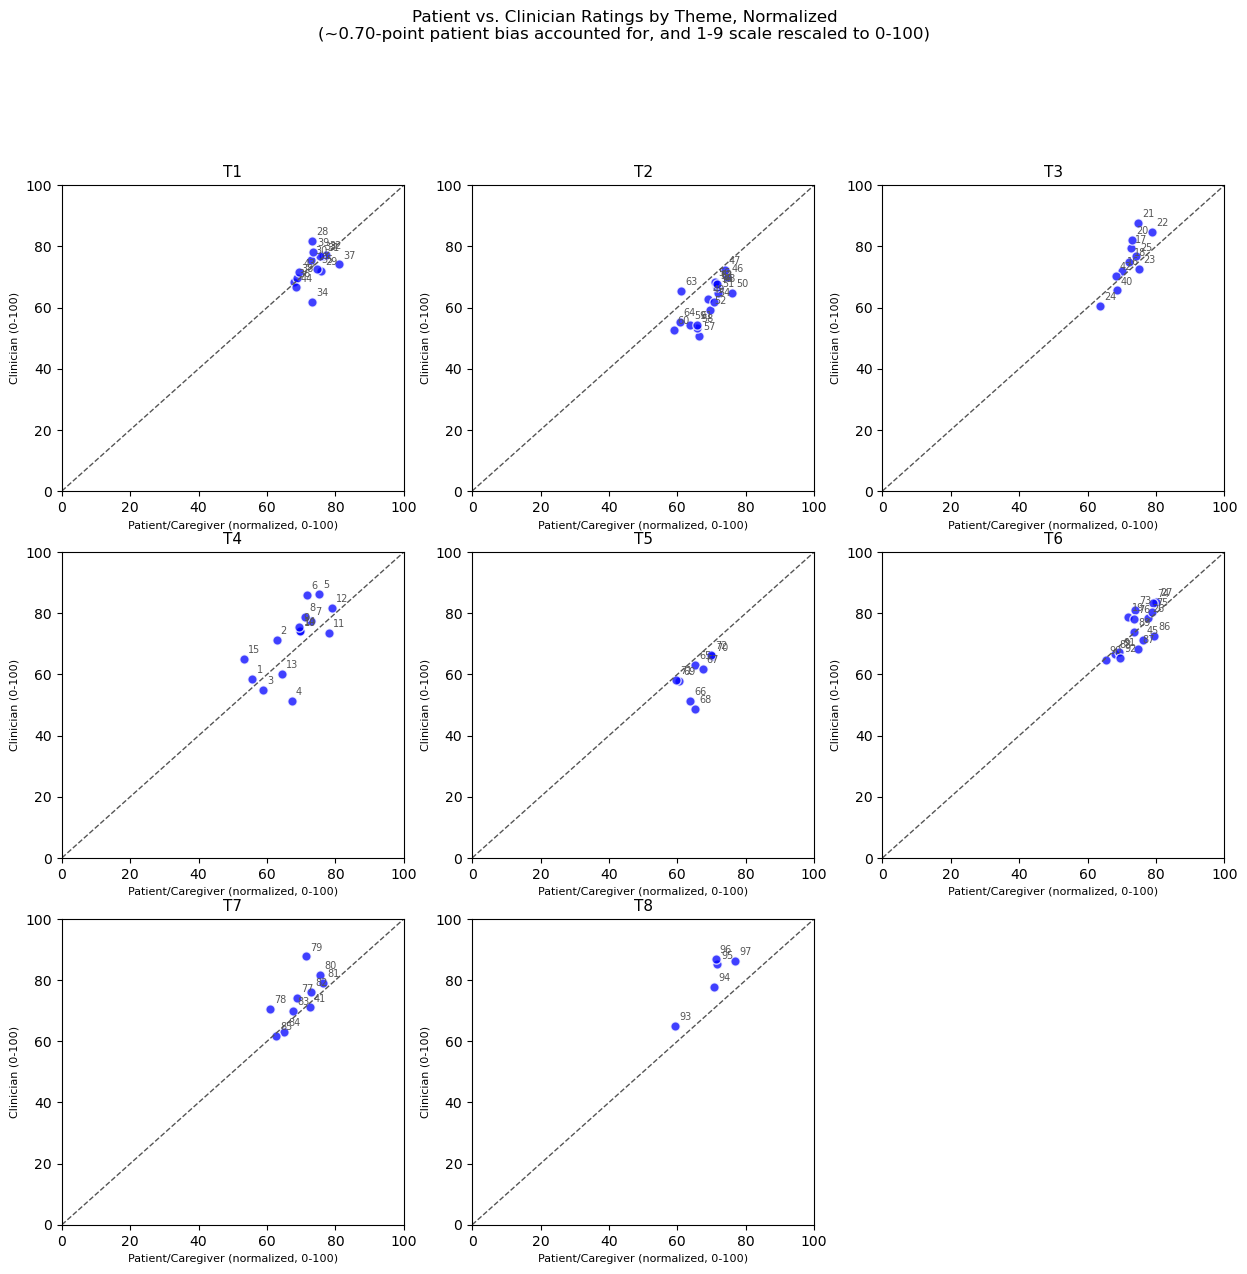

In [139]:
# make sure the themes are in numerical order
theme_number_order = ['T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8']

# assign figure size and axes 
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows))
axes = axes.flatten()

for ax, theme in zip(axes, theme_number_order):
    grp = q_means[q_means['theme_display'] == theme]

    ax.scatter(grp['L_norm_scaled'], grp['R_scaled'], alpha=0.75, s=45, color='Blue', edgecolors='white')

    # label each point 
    for _, row in grp.iterrows():
        # small text, align text on the left/bottom, and move the label 3 pixels up and 3 over 
        ax.annotate(
            str(int(row['question_number'])),
            (row['L_norm_scaled'], row['R_scaled']),
            fontsize=7, ha='left', va='bottom',
            xytext=(3, 3), textcoords='offset points', color='#555'
        )

    # add extra space around data, find min/max values to get the highest and lowest across both axes 
    pad = 0.5
    lo = min(x.min(), y.min()) - pad
    hi = max(x.max(), y.max()) + pad

    ax.plot([0, 100], [0, 100], color='#555', linestyle='--', linewidth=1)
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.set_title(theme, fontsize=11)
    ax.set_xlabel('Patient/Caregiver (normalized, 0-100)', fontsize=8)
    ax.set_ylabel('Clinician (0-100)', fontsize=8)

# hide unused subplot slots (7 themes in a 3x3 grid leaves 2 empty)
for ax in axes[len(theme_number_order):]:
    ax.axis('off')

fig.suptitle(f'Patient vs. Clinician Ratings by Theme, Normalized\n(~{overall_gap:.2f}-point patient bias accounted for, and 1-9 scale rescaled to 0-100)', y=1.01)
# plt.tight_layout()
# plt.show()

## SCATTERPLOTS (CONT)
** set axes to the same scale for all graphs in the scatter plot

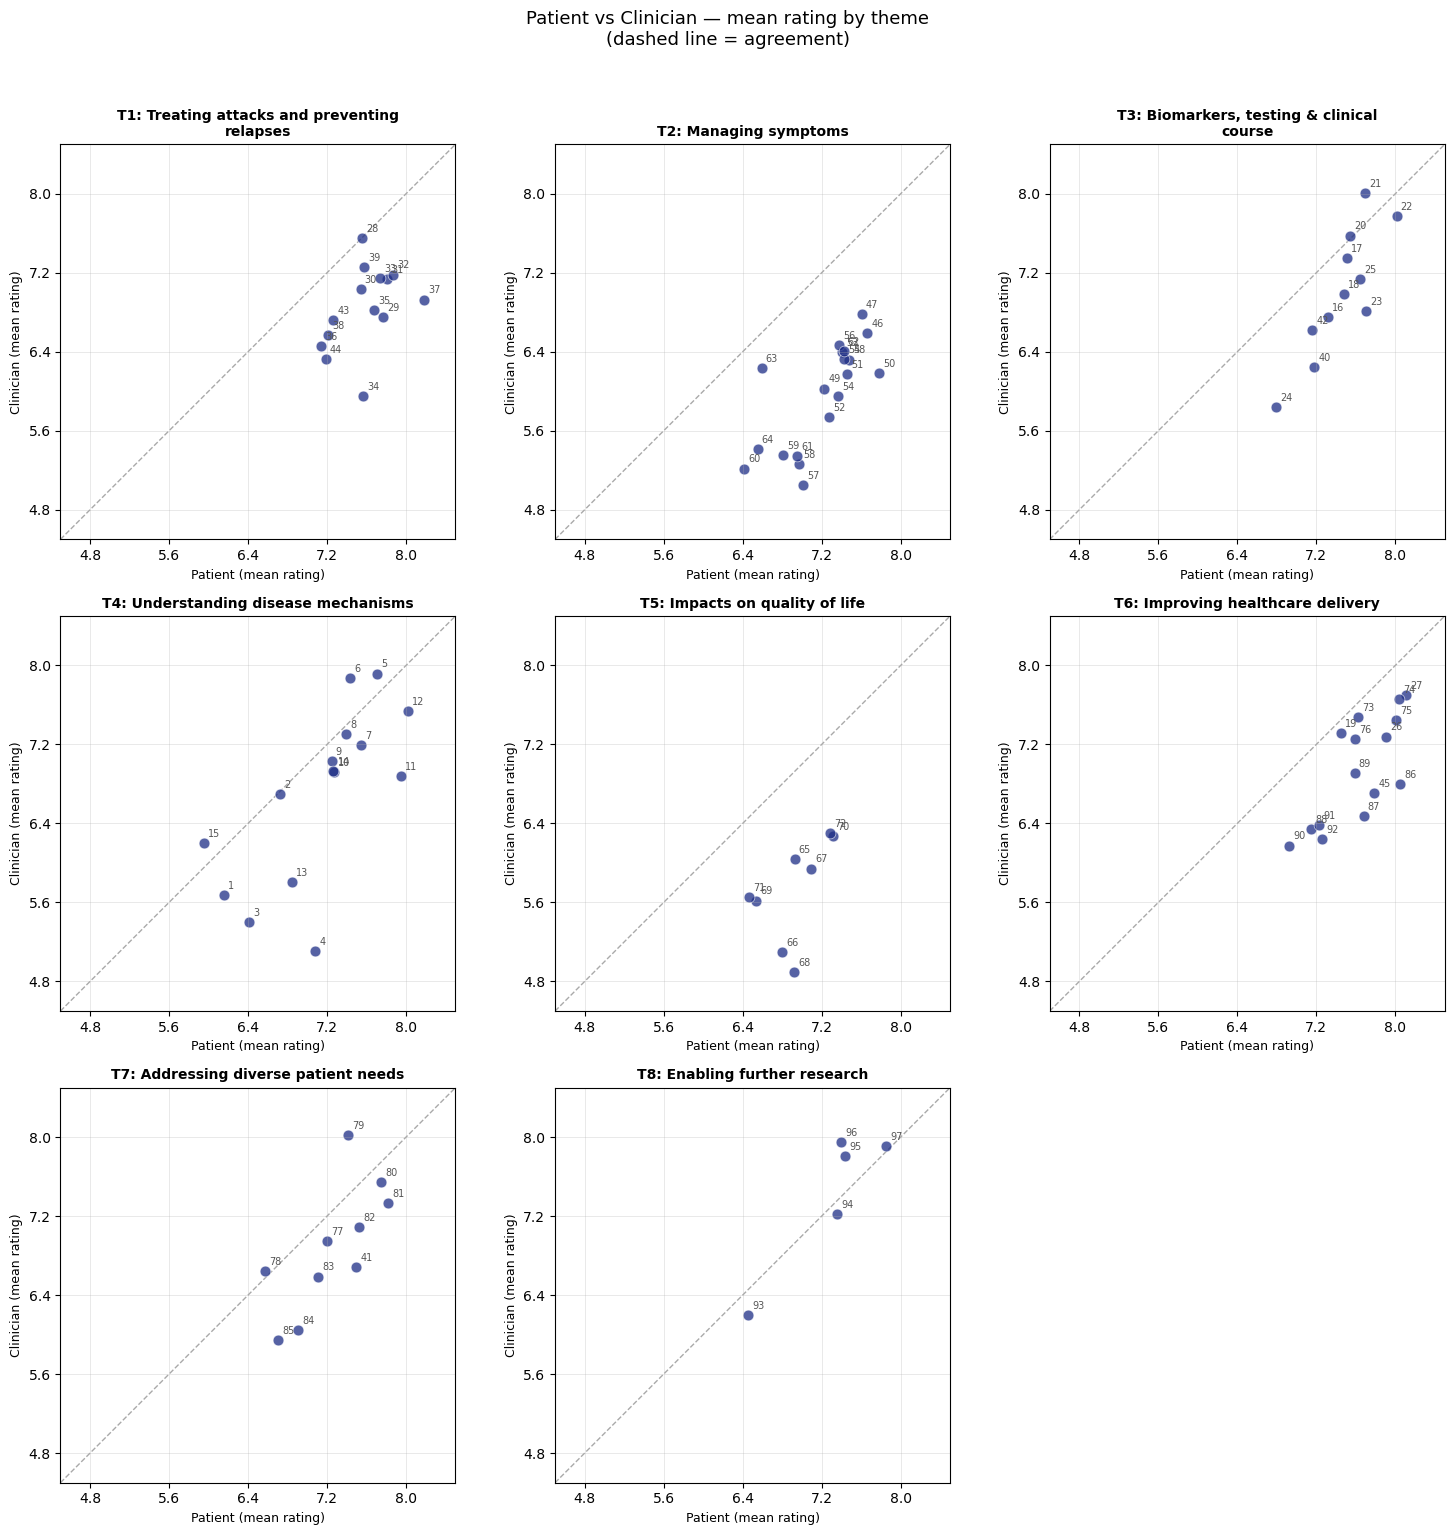

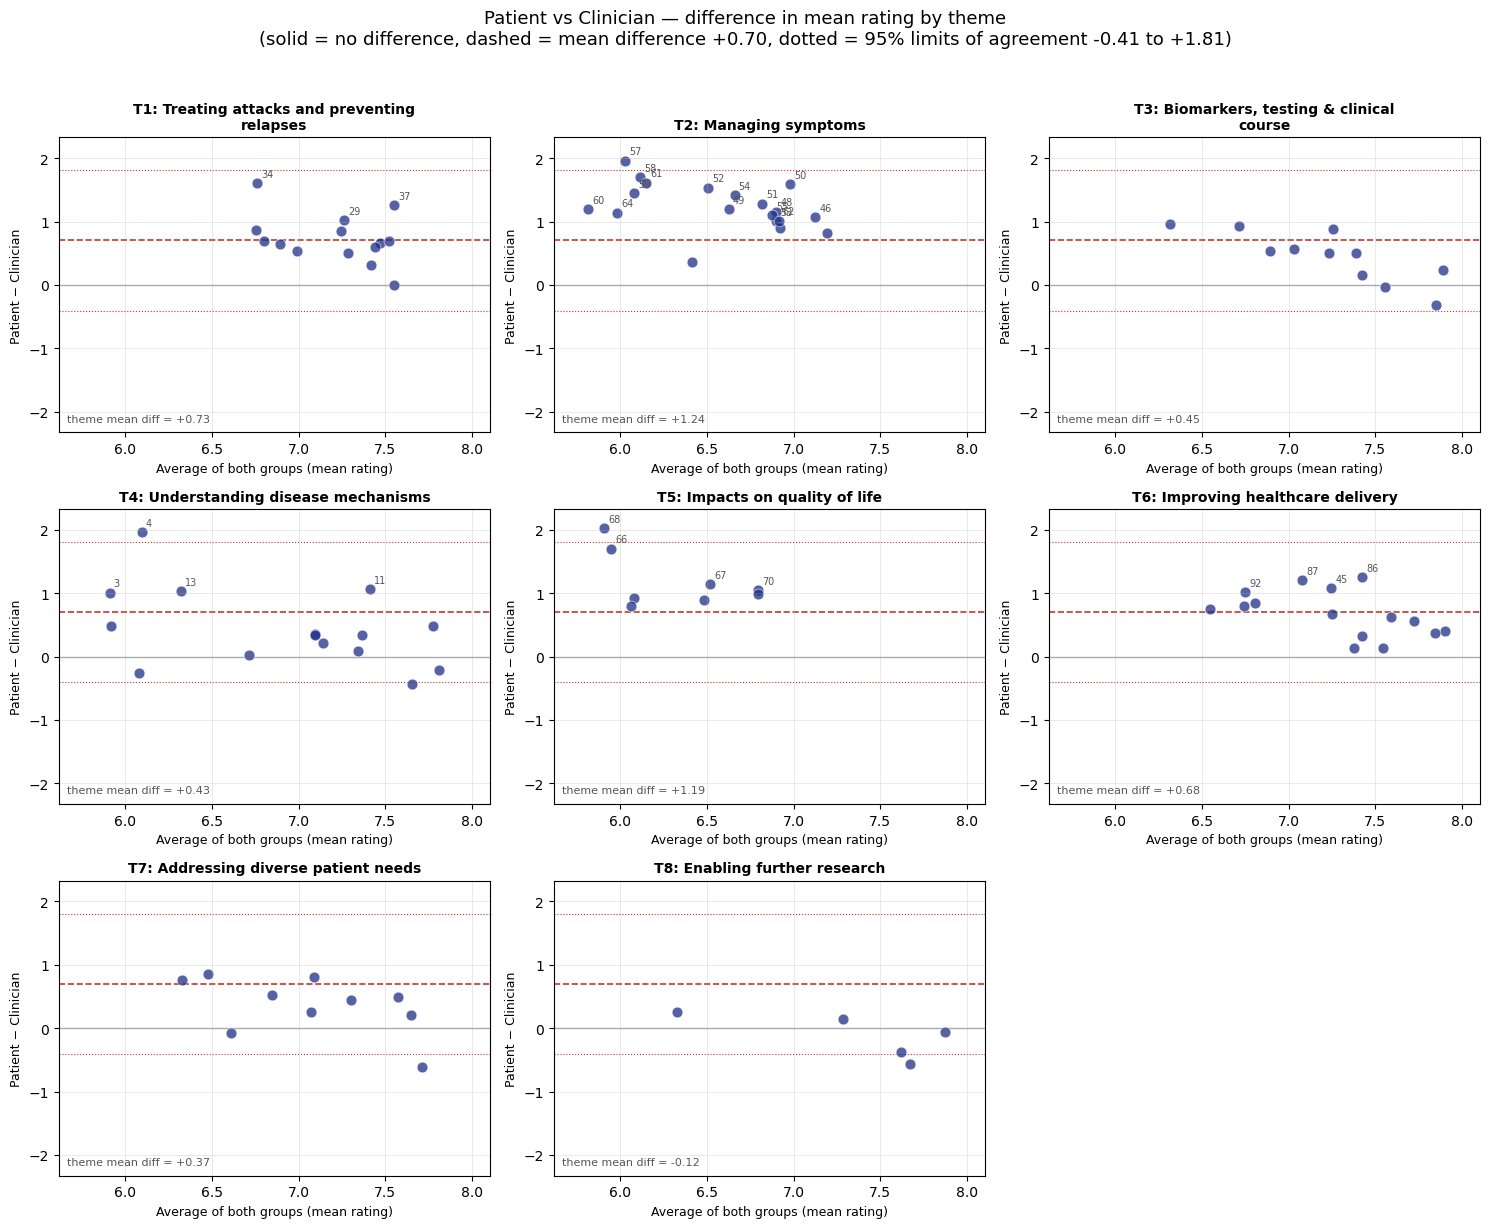

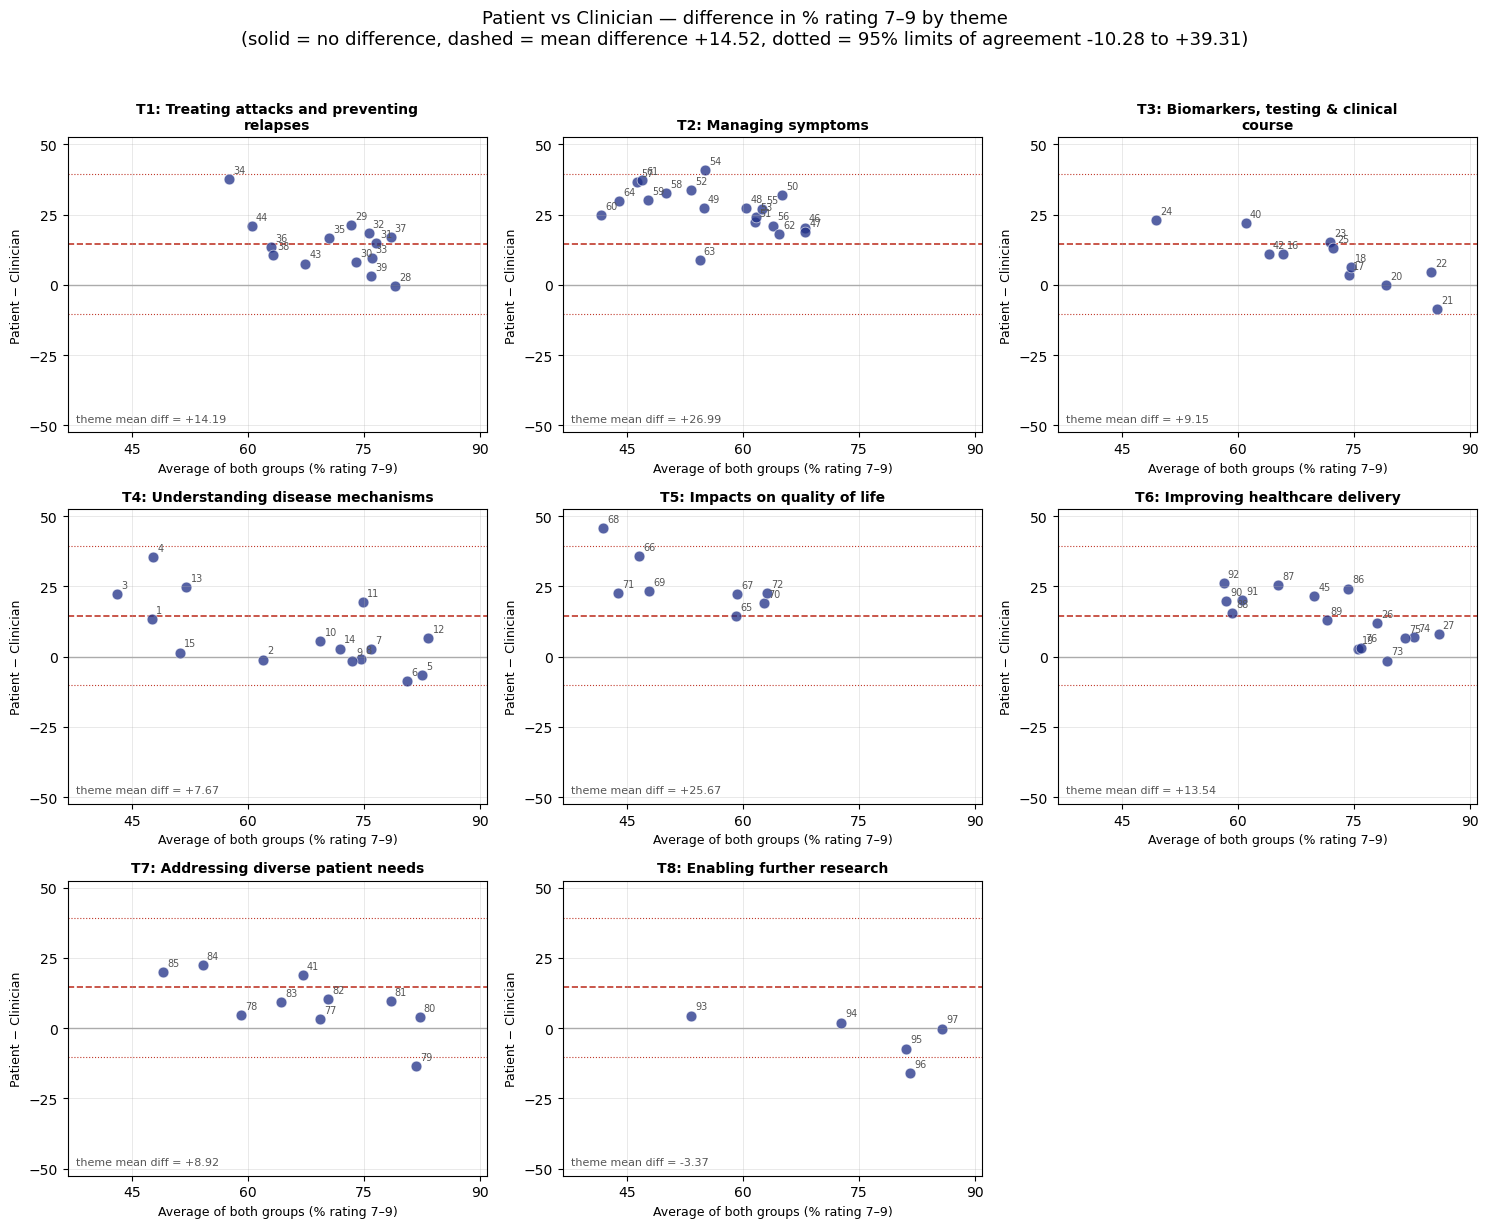

In [140]:
m = summarize_comparison(scatterplot_df, 'Lived Experience (L) or Professional/Researcher (R)', 'L', ['R'])

# column comparison 
plot_column_comparison_for_BA(m, 'Patient', 'Clinician', theme_description_tier_ranges, theme_label_map, axis_limits=(4.5, 8.5))

# Bland-Altman (difference plot), labelling only items that differ by 1+ point
plot_bland_altman(m, 'Patient', 'Clinician', theme_description_tier_ranges, theme_label_map, label_threshold=1)

# same plots using % rating 7–9 instead of means
plot_bland_altman(m, 'Patient', 'Clinician', theme_description_tier_ranges, theme_label_map, metric='pct_high')


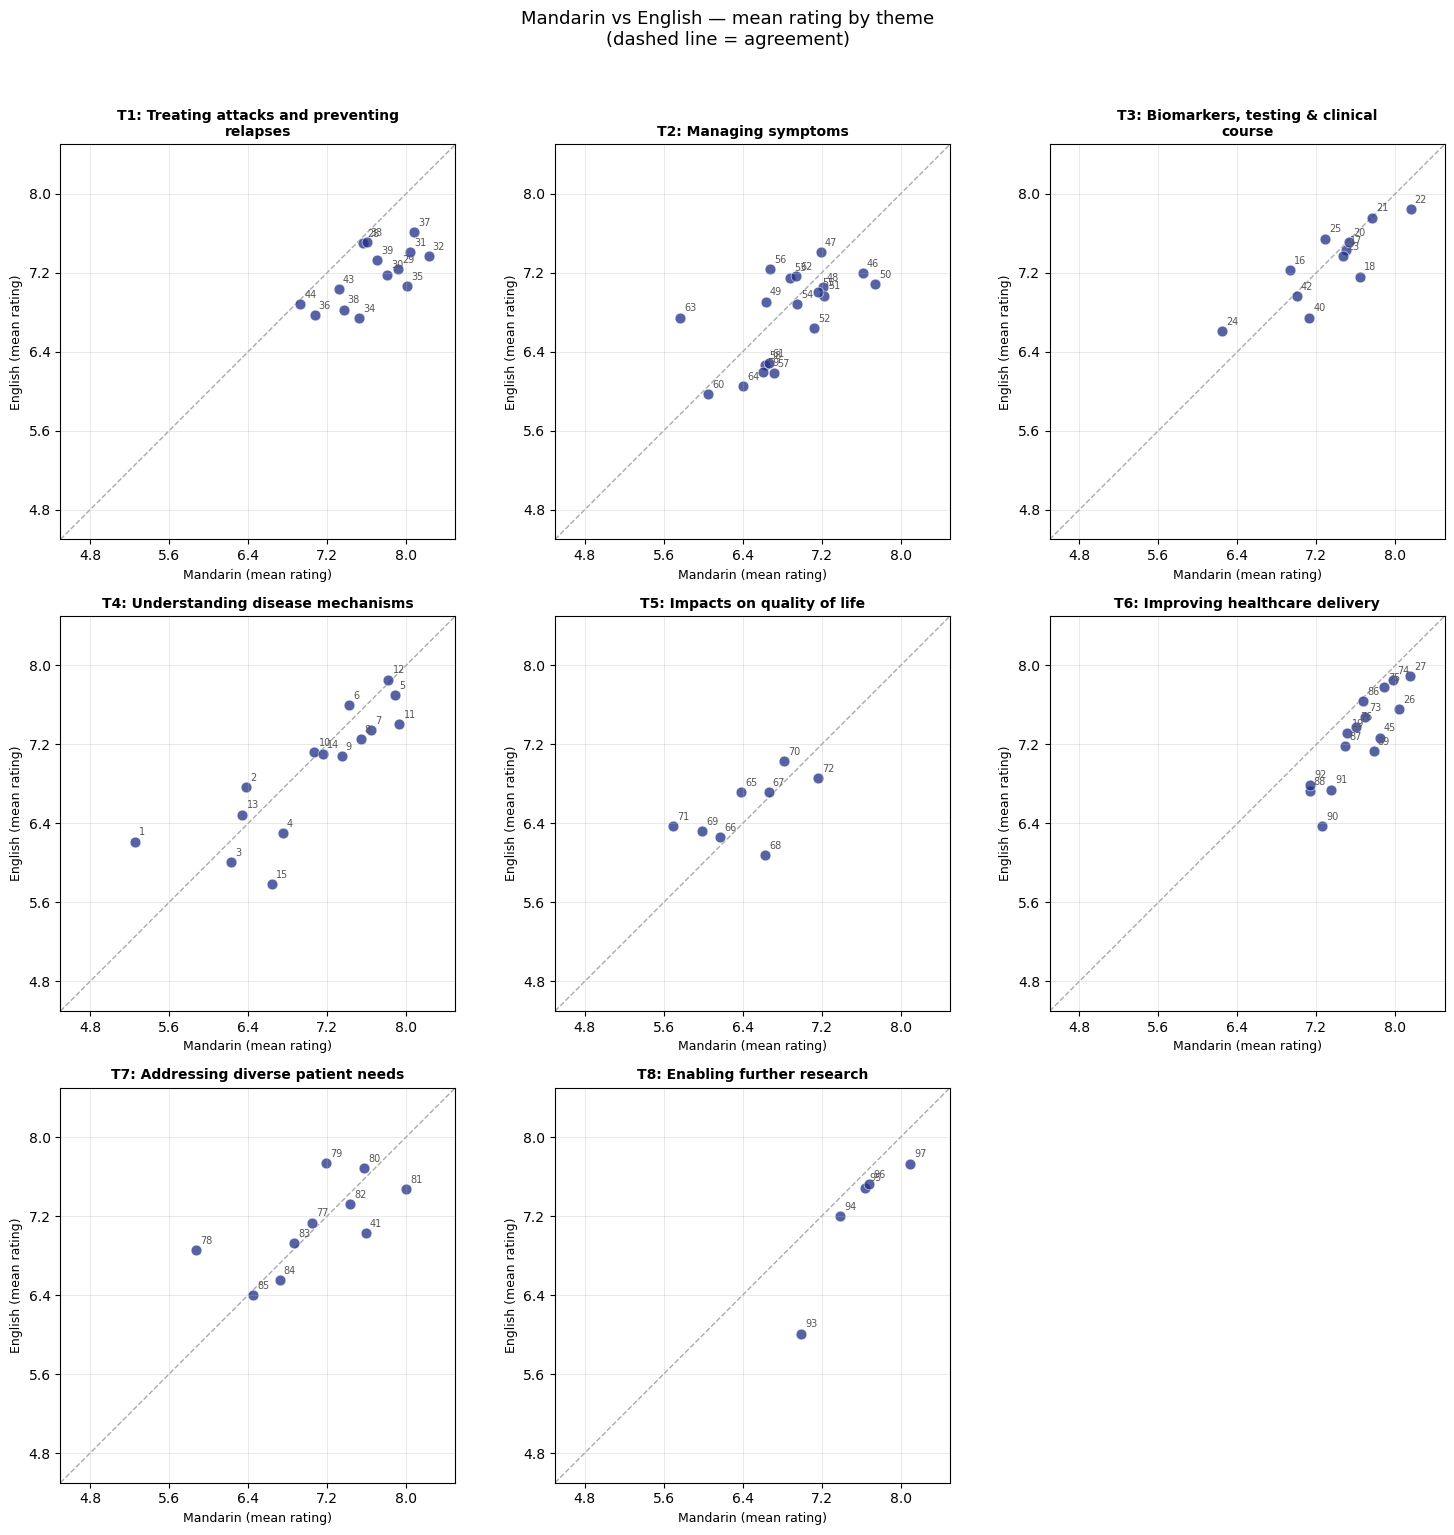

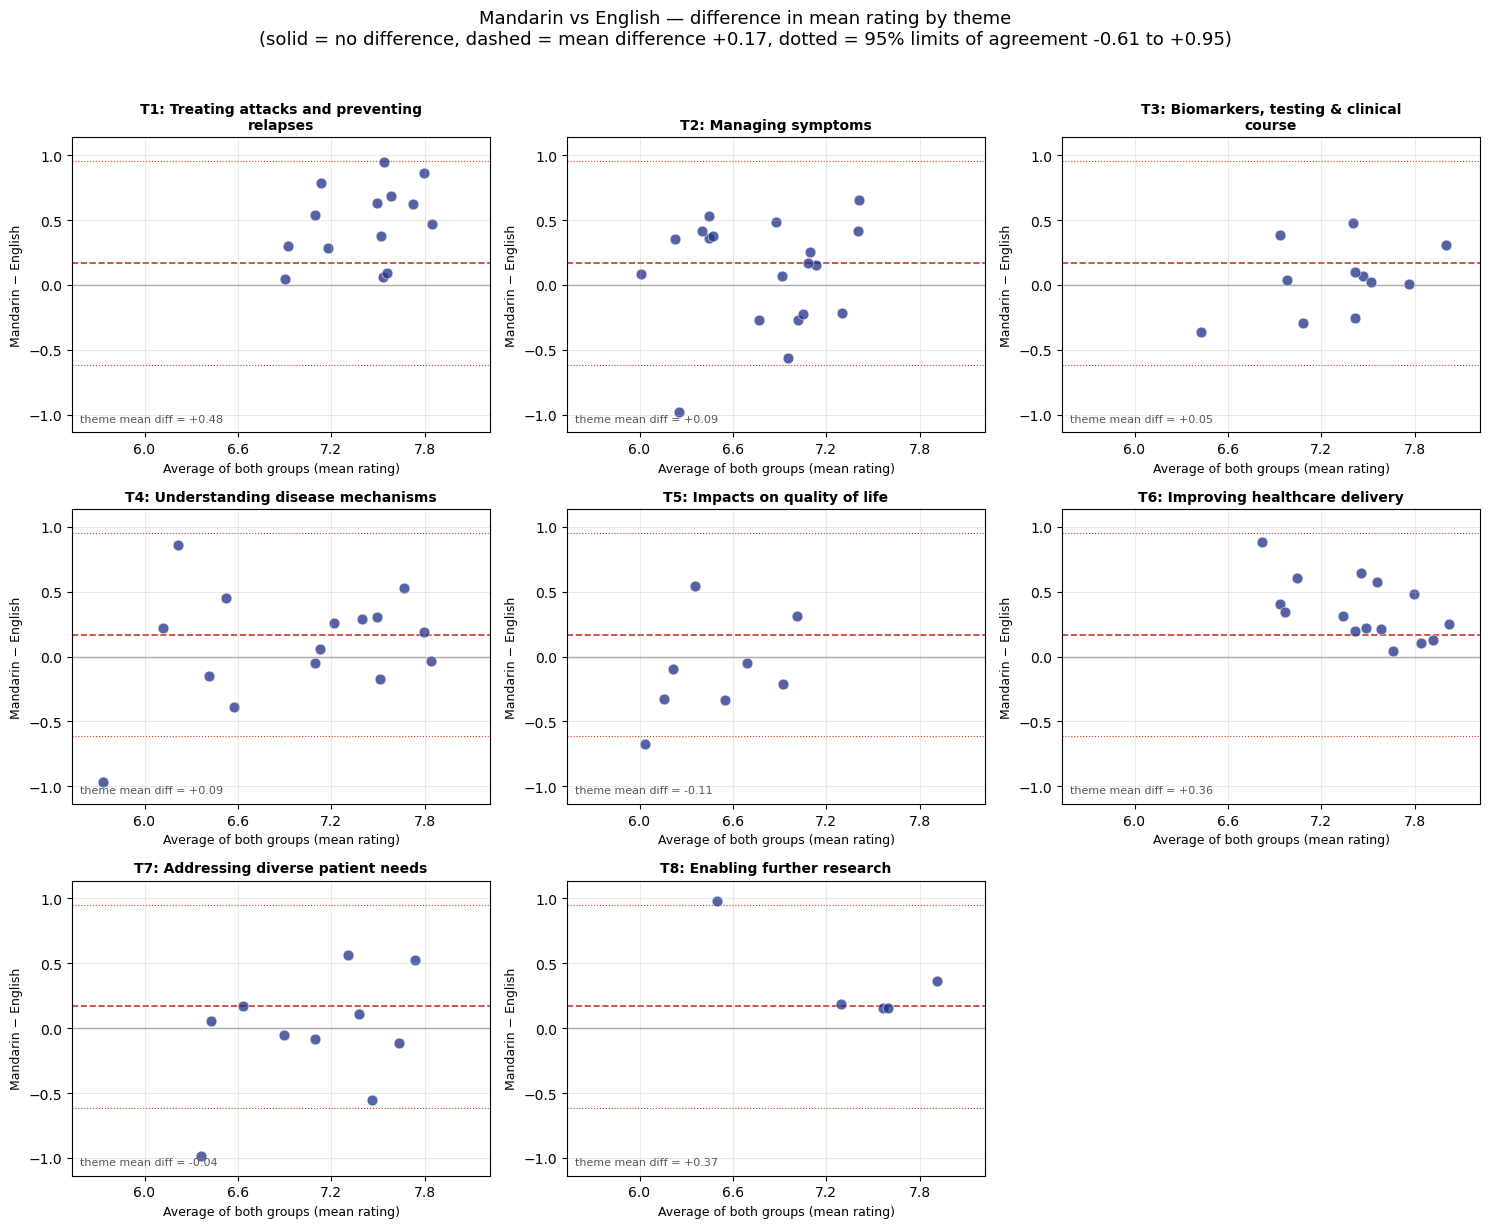

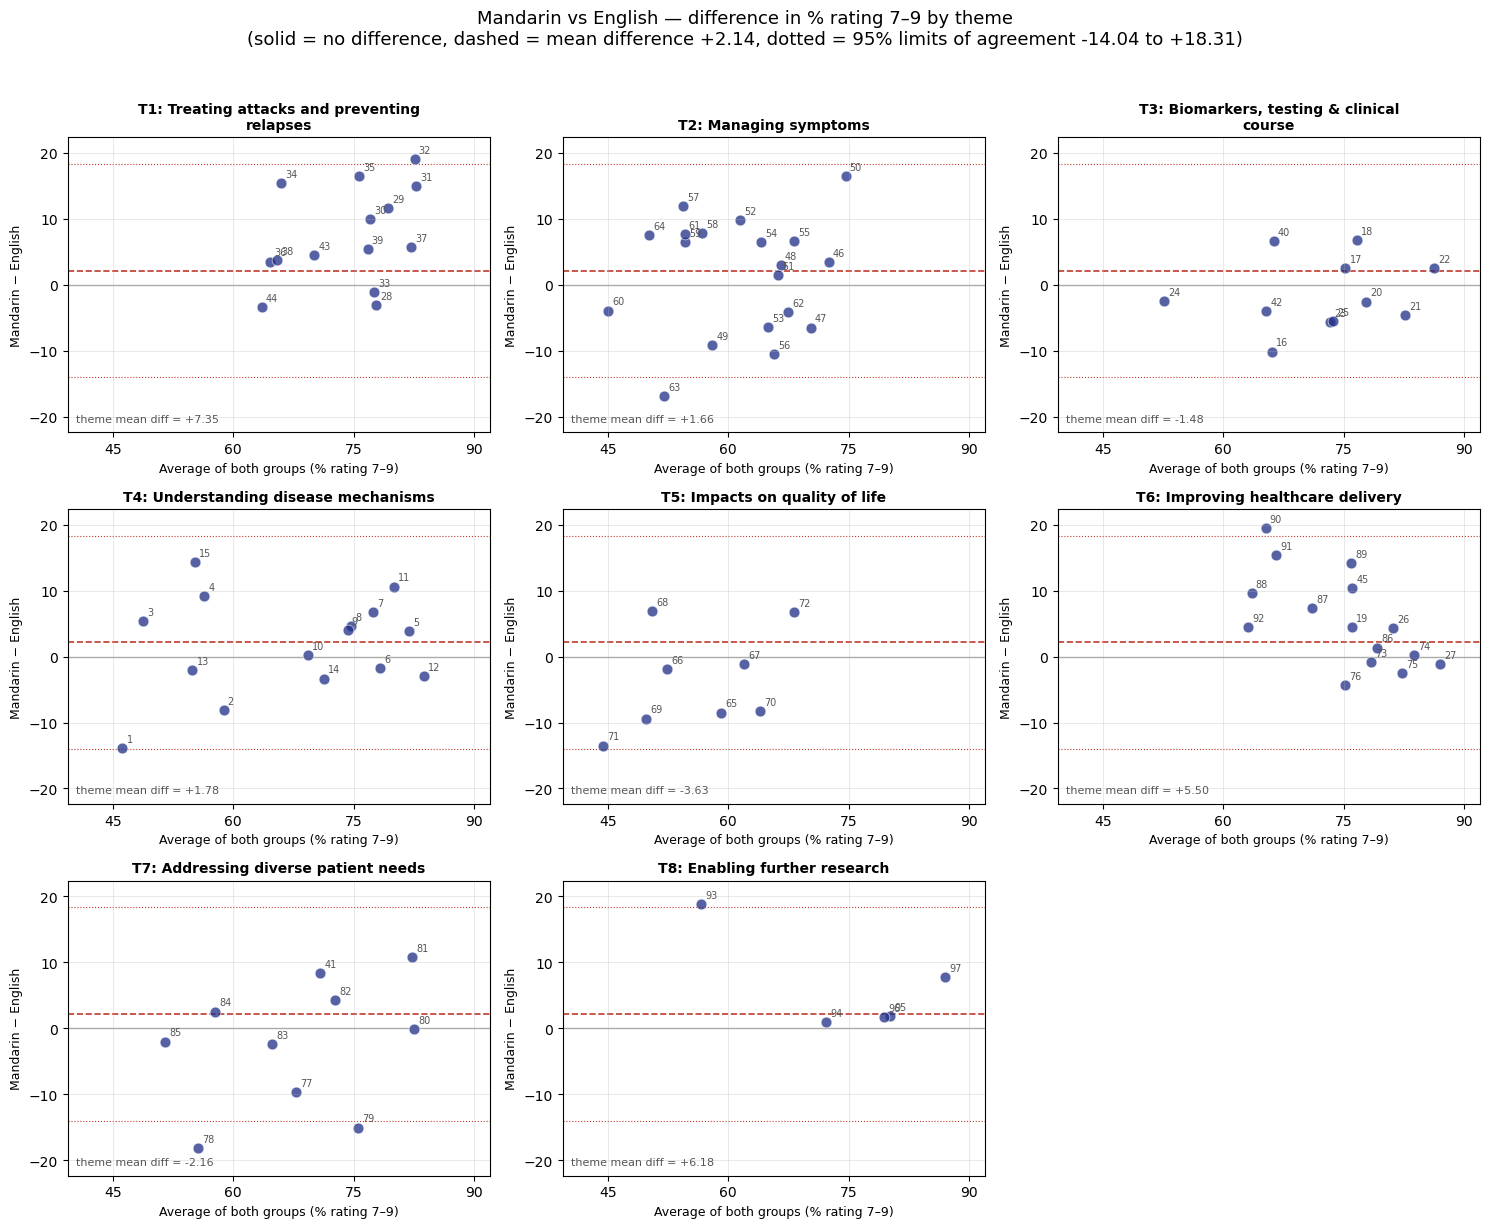

In [142]:
m = summarize_comparison(scatterplot_df, 'Language that survey was completed in', 'Mandarin', ['English'])

# column comparison 
plot_column_comparison_for_BA(m, 'Mandarin', 'English', theme_description_tier_ranges, theme_label_map, axis_limits=(4.5, 8.5))

# Bland-Altman (difference plot), labelling only items that differ by 1+ point
plot_bland_altman(m, 'Mandarin', 'English', theme_description_tier_ranges, theme_label_map, label_threshold=1)

# same plots using % rating 7–9 instead of means
plot_bland_altman(m, 'Mandarin', 'English', theme_description_tier_ranges, theme_label_map, metric='pct_high')

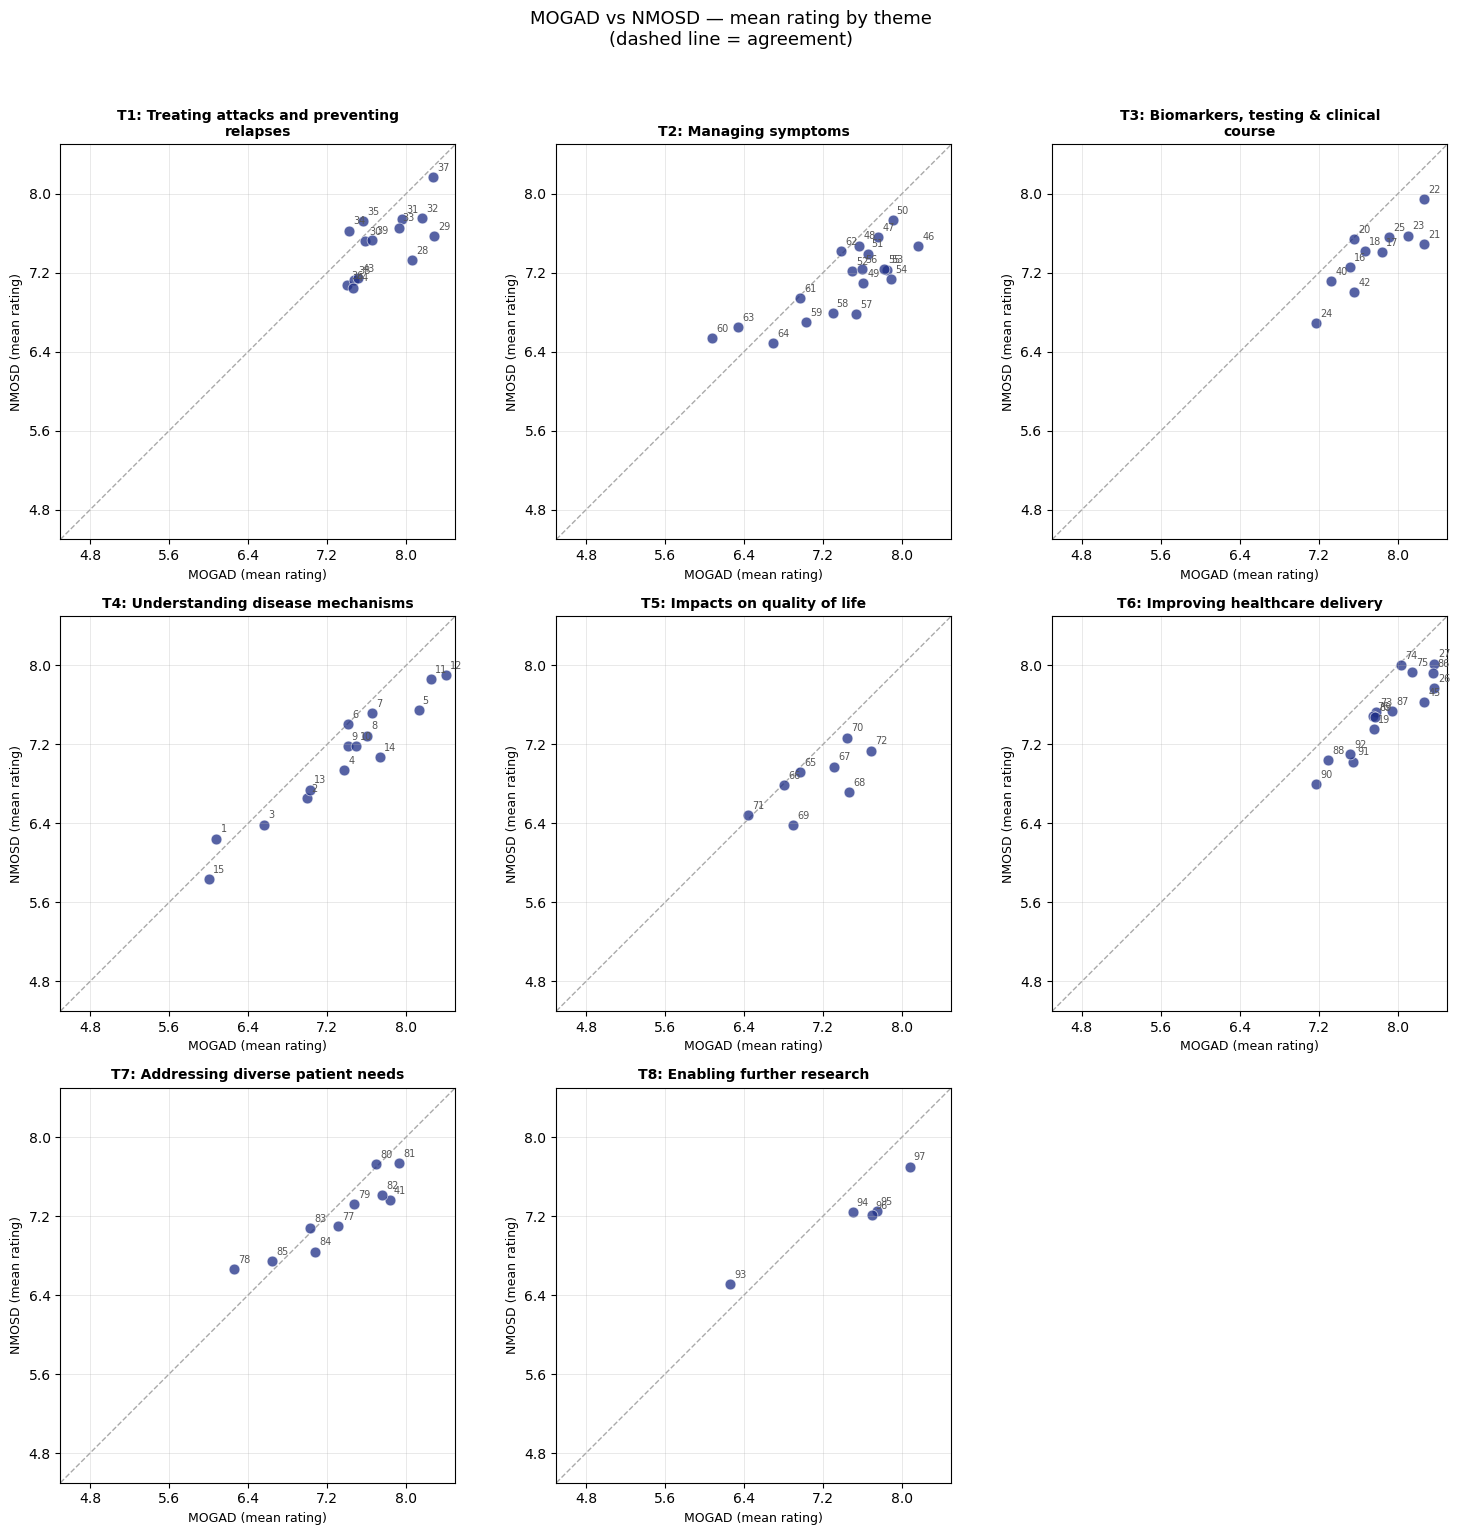

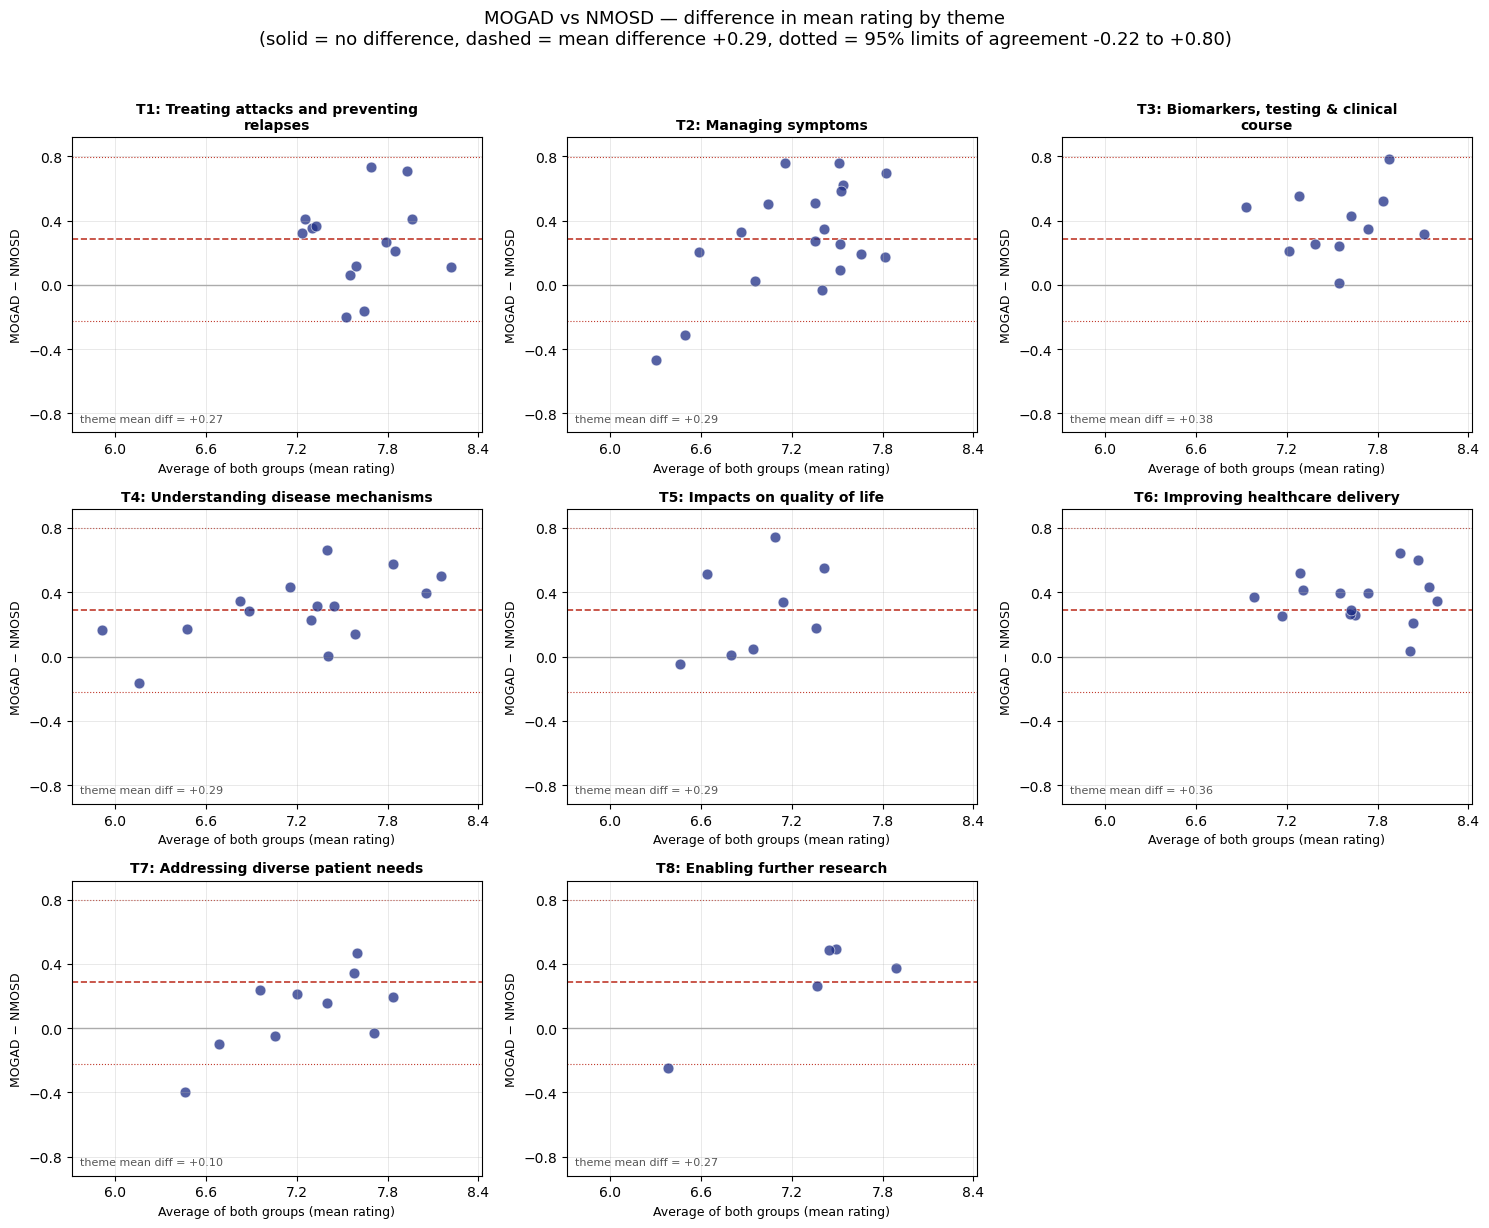

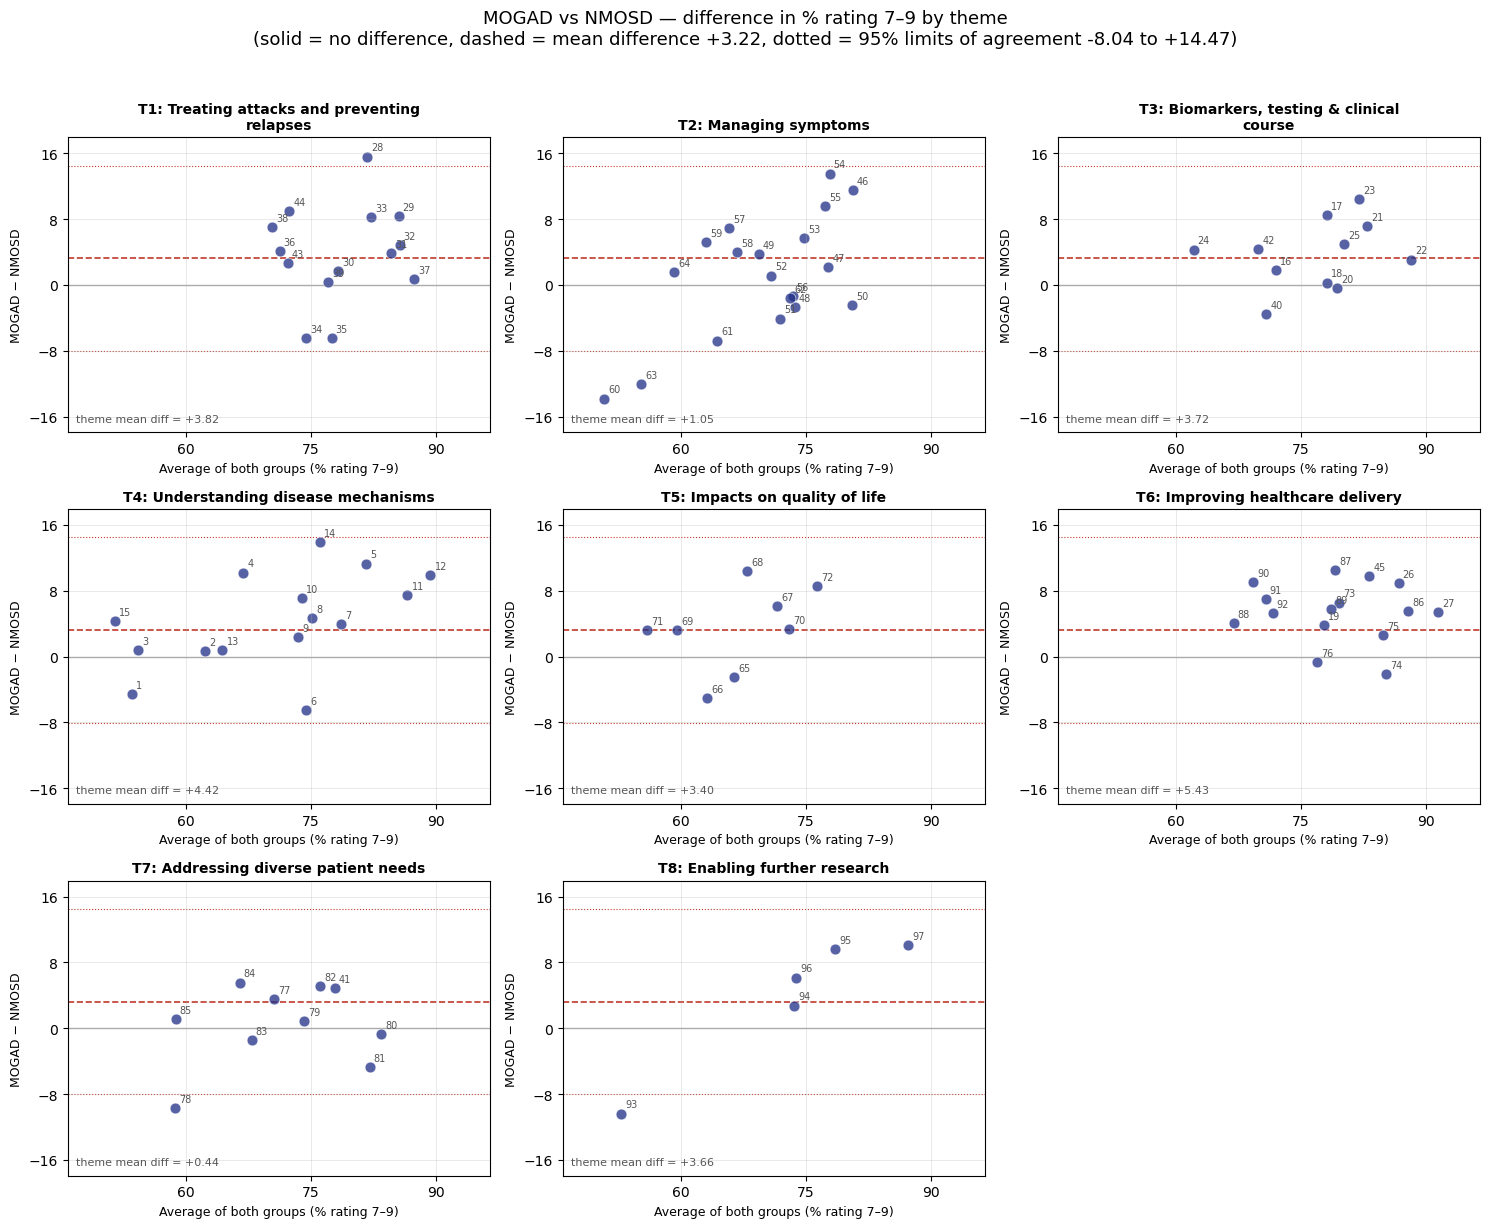

In [ ]:
m = summarize_comparison(scatterplot_df, 'NMOSD (N), MOGAD (M), Seronegative (S), Other (O)', 'M', ['N', 'S'])

# column comparison 
plot_column_comparison_for_BA(m, 'MOGAD', 'NMOSD', theme_description_tier_ranges, theme_label_map, axis_limits=(4.5, 8.5))

# Bland-Altman (difference plot), labelling only items that differ by 1+ point
plot_bland_altman(m, 'MOGAD', 'NMOSD', theme_description_tier_ranges, theme_label_map, label_threshold=1)

# same plots using % rating 7–9 instead of means
plot_bland_altman(m, 'MOGAD', 'NMOSD', theme_description_tier_ranges, theme_label_map, metric='pct_high')

## SUBGROUP ANALYSIS 
How high are patient scores on average when compared to clinician scores

In [ ]:
# get the mean and median rating differences per question between Lived Experience (LE) and Researchers (R)
question_gap = (
    df1_long.dropna(subset=['rating'])
    .groupby(['theme', 'question_number', 'question_text', experience_col])['rating']
    .agg(mean='mean', median='median', n='count')
    .reset_index()
)

# pivot so L and R are next to each other per question
pivot = question_gap.pivot_table(
    index=['theme', 'question_number', 'question_text'],
    columns=experience_col,
    values=['mean', 'median', 'n']
).reset_index()

# flatten the multi-level columns
pivot.columns = ['_'.join(col).strip('_') if col[1] else col[0] for col in pivot.columns]

# calculate gaps
pivot['mean_diff'] = pivot['mean_L'] - pivot['mean_R']
pivot['median_diff'] = pivot['median_L'] - pivot['median_R']
# % higher, relative to clinician rating
pivot['pct_diff'] = (pivot['mean_diff'] / pivot['mean_R']) * 100  

question_gap_df = pivot.sort_values('mean_diff', ascending=False)

print(f"Average mean_diff across all 97 items: {question_gap_df['mean_diff'].mean():.3f}")
print(f"Items where patients/caregivers rated higher: {(question_gap_df['mean_diff'] > 0).sum()} / {len(question_gap_df)}")
print(f"Items where clinicians rated higher: {(question_gap_df['mean_diff'] < 0).sum()} / {len(question_gap_df)}")

question_gap_df[['theme', 'question_text', 'mean_L', 'mean_R', 'mean_diff', 'pct_diff']].head(10)

Average mean_diff across all 97 items: 0.701
Items where patients/caregivers rated higher: 87 / 97
Items where clinicians rated higher: 10 / 97


,theme,question_text,mean_L,mean_R,mean_diff,pct_diff
62,T5,Heat intolerance,6.920168,4.895238,2.024930,41.365301
53,T4,Stress,7.078947,5.108333,1.970614,38.576457
25,T2,Migraines,7.008439,5.046729,1.961710,38.870917
26,T2,Seizures,6.969432,5.261682,1.707750,32.456351
60,T5,Complementary/alternative therapies,6.799163,5.095238,1.703925,33.441520
29,T2,Vocal cord paralysis and dysphagia,6.953191,5.339623,1.613569,30.218781
6,T1,Stem cell transplantation,7.564315,5.954955,1.609360,27.025568
18,T2,Paralysis,7.777311,6.185185,1.592126,25.740955
20,T2,Banding,7.273109,5.738318,1.534791,26.746366
27,T2,Nausea and vomiting,6.807531,5.355140,1.452391,27.121441


Per theme differences

In [ ]:
# make sure the themes are in numerical order
theme_number_order = ['T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8']

# calculate the average of the per-item gaps (each question weighted equally, not factoring in number of people who answered)
theme_gap_avg_of_items = (
    question_gap_df.groupby('theme')['mean_diff']
    .agg(avg_item_gap='mean', n_items='count')
    .reindex(theme_number_order)  # keep your standard T1->T6 ordering
)

# pooled gap (weighted so every individual rating is counted once; items that are more answered have more weight)
theme_gap_pooled = (
    df1_long.dropna(subset=['rating'])
    .groupby(['theme', experience_col])['rating']
    .mean()
    .unstack()
)
theme_gap_pooled['pooled_gap'] = theme_gap_pooled['L'] - theme_gap_pooled['R']
theme_gap_pooled = theme_gap_pooled.reindex(theme_number_order)

# sumarize by concatenating tables
theme_summary = pd.concat([
    theme_gap_avg_of_items[['avg_item_gap', 'n_items']],
    theme_gap_pooled[['L', 'R', 'pooled_gap']]
], axis=1)

theme_summary.columns = ['avg_item_gap', 'n_items', 'mean_L', 'mean_R', 'pooled_gap']
theme_summary

,avg_item_gap,n_items,mean_L,mean_R,pooled_gap
theme,,,,,
T1,0.730983,14,7.580130,6.844660,0.735470
T2,1.239026,19,7.200529,5.962872,1.237656
T3,0.447975,11,7.456403,7.008177,0.448226
T4,0.433156,15,7.129997,6.697331,0.432666
T5,1.189931,8,6.917629,5.730178,1.187451
T6,0.680030,15,7.629462,6.958756,0.670705
T7,0.365881,10,7.244871,6.883633,0.361238
T8,-0.118463,5,7.298338,7.424762,-0.126424


Gap per theme: ranked bar chart <br>
at 0, patients and clinicians rate each theme the same.

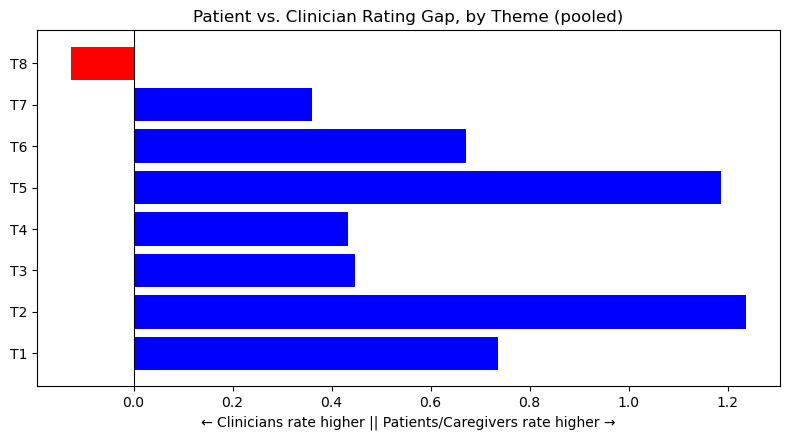

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ['Blue' if v > 0 else 'Red' for v in theme_summary['pooled_gap']]
ax.barh(theme_summary.index, theme_summary['pooled_gap'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('← Clinicians rate higher || Patients/Caregivers rate higher →')
ax.set_title('Patient vs. Clinician Rating Gap, by Theme (pooled)')
plt.tight_layout()
plt.show()

Gap per question: ranked bar chart

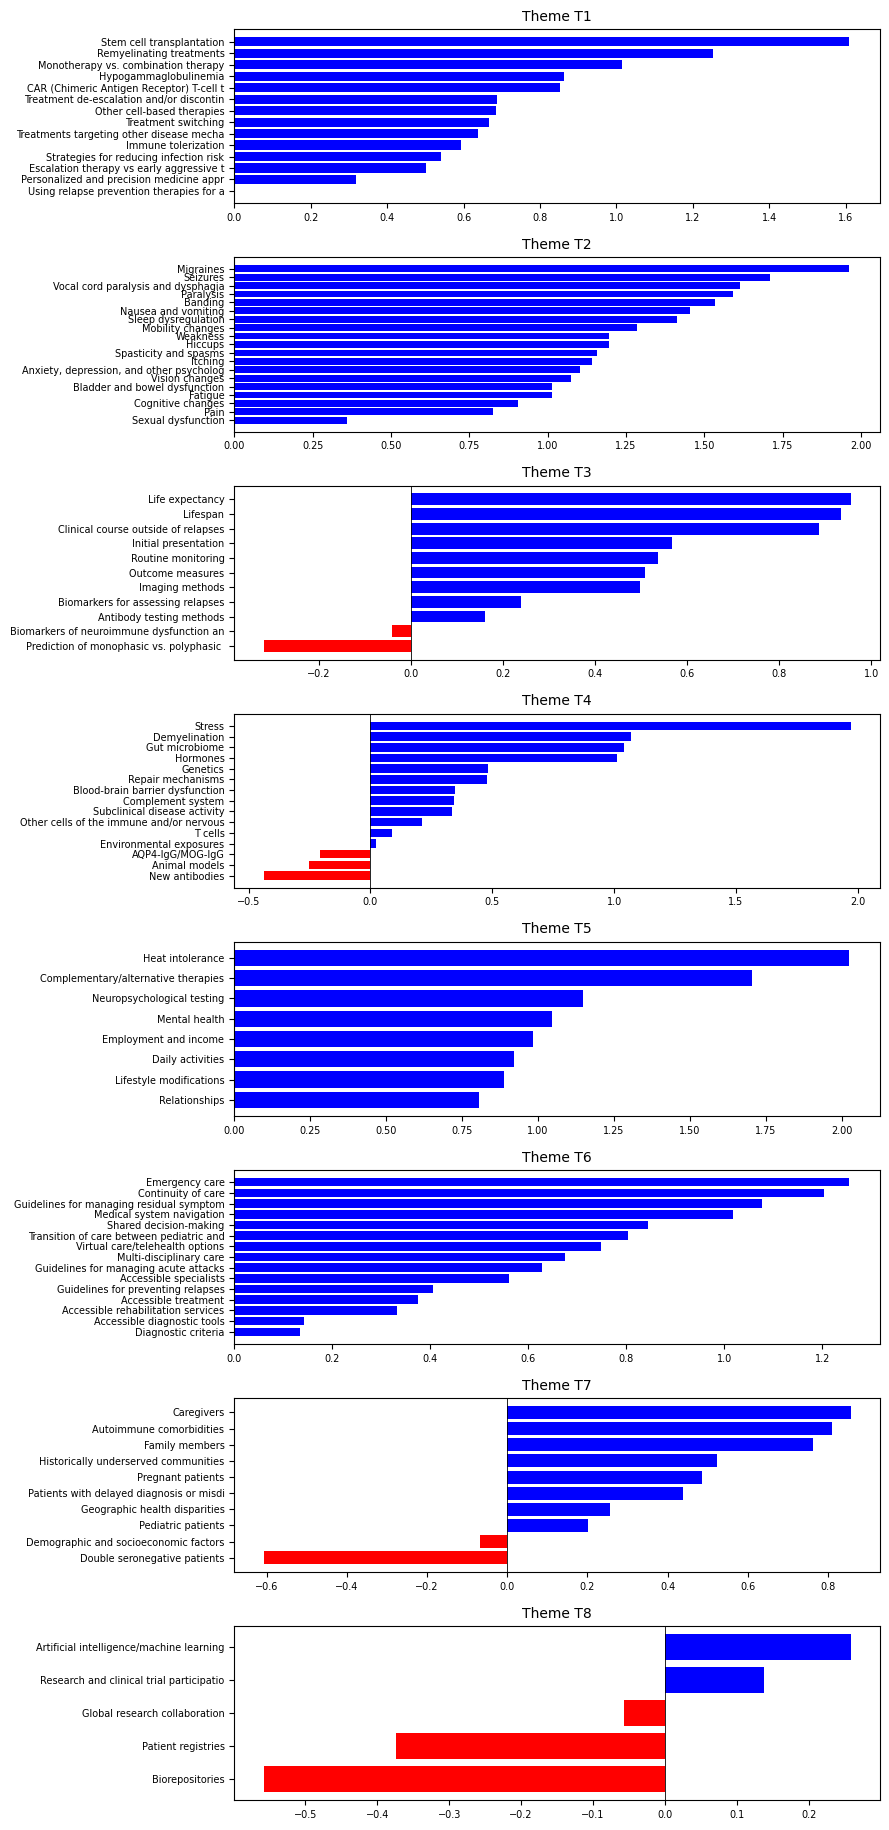

In [ ]:
# separate it by question within each theme 
n_themes = question_gap_df['theme'].nunique()
fig, axes = plt.subplots(n_themes, 1, figsize=(9, 2.3 * n_themes))

for ax, (theme, grp) in zip(axes, question_gap_df.groupby('theme', sort=True)):
    grp = grp.sort_values('mean_diff')
    colors = ['Blue' if v > 0 else 'Red' for v in grp['mean_diff']]
    ax.barh(grp['question_text'].str.slice(0, 40), grp['mean_diff'], color=colors)
    ax.axvline(0, color='black', linewidth=0.6)
    ax.set_title(f'Theme {theme}', fontsize=10)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()

### --